# 02 – Modellen: van decision tree tot stacking

| | |
|---|---|
| **Auteur(s)** | Kobe Vandenberk *(vul teamleden aan)* |
| **Wat** | Een decision tree en een random forest bouwen en tunen. Daarna **alles proberen wat de score zou kunnen verhogen** (PyCaret, gradient boosting, XGBoost, stacking, andere preprocessing, labelruis wegfilteren) en aantonen **waarom** dat niet werkt. Tot slot een veilige drempelwaarde kiezen (met een zone "onzeker"), één keer eerlijk testen op de vaste testset en de fouten analyseren. |
| **Input** | `data/clean/mushrooms_clean.parquet`, `data/clean/test_ids.json` (uit `01_data_cleaning.ipynb`) |
| **Output** | `models/decision_tree.pkl`, `models/random_forest.pkl`, `models/metrics/decision_tree.json`, `models/metrics/random_forest.json` |

## Omgeving
Deze notebook draait in **`venv_pycaret` (Python 3.11)**: PyCaret 3.3 werkt **niet** met Python 3.12+ (zie `Exercises_solved/3 model quality/5.1 - Install PyCaret.ipynb`). We pinnen **`lightgbm==4.5.0`**: met de nieuwste versie (4.7) crasht LightGBM op Windows (`OSError: access violation`), en dan laat PyCaret het model stilletjes weg uit de vergelijking. Zie `README.md` voor de installatie.

## De vraag
Gegeven de kenmerken van een paddenstoel: is hij **giftig** (1) of **eetbaar** (0)?

**Belangrijkste metrics:**
- **Recall op "giftig"**: een giftige paddenstoel als eetbaar voorspellen (false negative) kan dodelijk zijn. Een eetbare als giftig voorspellen kost enkel een gemiste maaltijd.
- **AUC**: hoe goed het model giftig en eetbaar uit elkaar houdt, los van de drempelwaarde. Daarop kiezen en tunen we de modellen.

## Opbouw
| Stap | Inhoud |
|---|---|
| 1–3 | Preprocessing, baseline, tuning van een **decision tree** en een **random forest** |
| 4 | **Kan het beter?** PyCaret (alle modellen), gradient boosting, XGBoost, stacking, andere preprocessing en een test van de cleaningkeuzes uit `01`, met een overzicht en een verklaring |
| 5 | Drempelwaarde, drie zones (eetbaar / onzeker / giftig) en het combineren van twee drempels |
| 6–8 | Eindtest op de testset (met betrouwbaarheidsintervallen), belangrijkste kenmerken, error analysis: **bewijs voor labelruis**, ontbrekende waarden, en **gecorrigeerde cijfers en drempel** |
| 9 | Opslaan |

## Waarom starten met deze twee modellen?
- **Decision tree**: eenvoudig, snel en uit te leggen ("als de steel glad is en de ring ontbreekt, dan…"). Goede eerste stap.
- **Random forest**: veel bomen op willekeurige stukken van de data (bagging), en dan stemmen. Minder gevoelig voor toevallige patronen, en dat is belangrijk want de labels zijn deels omgedraaid (zie `01`).

Bomen hebben geen schaling nodig en gaan goed om met categorieën en scheve verdelingen (grote soorten, zie `01` stap 7).

## 0. Imports en data

In [1]:
%matplotlib inline
import itertools
import json
import os
from pathlib import Path

# joblib telt de fysieke cores met `wmic`, dat niet meer bestaat op Windows 11, en print dan een lange waarschuwing.
# Die blijft enkel weg als LOKY_MAX_CPU_COUNT kleiner is dan het aantal logische cores.
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, (os.cpu_count() or 2) - 1))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pycaret.classification import compare_models, create_model, pull, setup, tune_model
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier, StackingClassifier, VotingClassifier)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from cleanlab.count import estimate_joint
from xgboost import XGBClassifier

SEED = 42
MODEL_DIR = Path("models")

df = pd.read_parquet("data/clean/mushrooms_clean.parquet")
test_ids = json.loads(Path("data/clean/test_ids.json").read_text())["test_ids"]

NUMERIC = ["cap_diameter_cm", "stem_height_cm", "stem_width_mm"]
CATEGORICAL = [c for c in df.columns if c not in NUMERIC + ["id", "class"]]

is_test = df["id"].isin(test_ids)
X = df[NUMERIC + CATEGORICAL]           # id is GEEN feature
y = (df["class"] == "poisonous").astype(int)  # 1 = giftig
X_train, X_test, y_train, y_test = X[~is_test], X[is_test], y[~is_test], y[is_test]

print(f"train: {len(X_train)} rijen ({y_train.mean():.1%} giftig) | test: {len(X_test)} rijen ({y_test.mean():.1%} giftig)")

train: 4000 rijen (37.9% giftig) | test: 1000 rijen (37.9% giftig)


## 1. Preprocessing in een pipeline

| Stap | Kolommen | Waarom |
|---|---|---|
| `SimpleImputer(strategy="median")` | numeriek | In `01` lieten we de NaN's bewust staan. De mediaan wordt nu **enkel op de trainset (per fold)** berekend → geen leakage. Mediaan i.p.v. gemiddelde omdat de verdelingen scheef zijn. |
| `OneHotEncoder(handle_unknown="ignore")` | categorisch | Bomen in scikit-learn kunnen niet met tekst werken. `"unknown"` wordt gewoon een eigen kolom. `handle_unknown="ignore"` voorkomt een crash als de webapp ooit een nieuwe waarde doorstuurt. |

Alles zit in **één pipeline** met het model. Zo gebeurt de preprocessing binnen elke cross-validation-fold opnieuw, en kan de backend straks ruwe invoer geven.

In [2]:
def make_model(estimator, numeric=NUMERIC, categorical=CATEGORICAL, num_step=None, cat_step=None, features=None):
    """Pipeline preprocessing + model. Met de extra argumenten passen we de preprocessing aan in stap 4."""
    preprocess = ColumnTransformer([
        ("num", num_step or SimpleImputer(strategy="median"), numeric),
        ("cat", cat_step or OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return make_pipeline(*[s for s in [features, preprocess, estimator] if s is not None])


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# AP (average precision) vat precision en recall op giftig samen, over alle drempels. Een nuttige aanvulling
# op AUC omdat giftig de kleinste klasse is (38%); een model dat gokt, haalt AP 0,38.
SCORING = {"AUC": "roc_auc", "accuracy": "accuracy", "recall giftig": "recall", "AP": "average_precision"}

## 2. Baseline: standaardinstellingen

We starten met drie modellen **zonder tuning**, met 5-fold cross-validation op de trainset:
- **Dummy** (voorspelt altijd de meest voorkomende klasse = eetbaar): de ondergrens. Een model dat niet beter doet, heeft niets geleerd.
- **Decision tree** en **random forest** met de standaardinstellingen van scikit-learn.

We tonen ook de score op de **trainset** zelf, om overfitting te zien.

In [3]:
BASELINES = {
    "Dummy": make_model(DummyClassifier(strategy="most_frequent")),
    "Decision tree (standaard)": make_model(DecisionTreeClassifier(random_state=SEED)),
    "Random forest (standaard)": make_model(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
}


FOLD_AUC = {}  # AUC per fold van elk model, voor de gepaarde vergelijking in stap 4


def cv_scores(model, label=None, X=None):
    X = X_train if X is None else X
    scores = cross_validate(model, X, y_train, cv=cv, scoring=SCORING, return_train_score=True)
    if label is not None:
        FOLD_AUC[label] = scores["test_AUC"]
    row = {f"CV {name}": scores[f"test_{name}"].mean() for name in SCORING}
    row["CV AUC std"] = scores["test_AUC"].std()
    row["train accuracy"] = scores["train_accuracy"].mean()
    return row


def paired(names, reference="Random forest (getuned)"):
    """Gepaarde vergelijking: alle modellen zijn op exact dezelfde 5 folds getest, dus we vergelijken fold per fold."""
    diff = {n: FOLD_AUC[n] - FOLD_AUC[reference] for n in names}
    return pd.DataFrame({"verschil AUC met RF": {n: d.mean() for n, d in diff.items()},
                         "spreiding verschil": {n: d.std() for n, d in diff.items()},
                         "folds beter dan RF": {n: int((d > 0).sum()) for n, d in diff.items()}})


results = pd.DataFrame({name: cv_scores(model, label=name) for name, model in BASELINES.items()}).T
results.round(3)

,CV AUC,CV accuracy,CV recall giftig,CV AP,CV AUC std,train accuracy
Dummy,0.500,0.621,0.000,0.378,0.000,0.621
Decision tree (standaard),0.695,0.713,0.620,0.529,0.007,1.000
Random forest (standaard),0.827,0.793,0.604,0.773,0.011,1.000


**Interpretatie:**
- De Dummy haalt 62% accuracy door altijd "eetbaar" te zeggen, maar vindt **geen enkele** giftige paddenstoel (recall 0) en heeft AUC 0,5. Accuracy alleen is hier dus misleidend.
- Beide boommodellen halen **100% op de trainset**, maar in cross-validation zakt dat naar 71% (boom) en 79% (forest). Een onbeperkte boom groeit tot elk blad één rij bevat: hij leert de trainset **uit het hoofd**, inclusief de omgedraaide labels. Dat is overfitting.
- De random forest doet het duidelijk beter dan één boom (AUC 0,83 vs 0,70): het middelen over veel bomen dempt die toevallige fouten.

## 3. Hyperparameter tuning

We tunen op **AUC**, met dezelfde 5 folds en **nooit op de testset**.

### 3a. Decision tree – grid search
Een boom heeft weinig belangrijke hyperparameters, dus een volledige grid is haalbaar (6 × 3 × 2 = 36 combinaties × 5 folds).

| Parameter | Wat doet het? |
|---|---|
| `max_leaf_nodes` | Maximaal aantal bladeren. De boom groeit dan *best-first*: eerst de splitsingen die het meest opleveren. Zo kan hij diep gaan waar dat nodig is en ondiep blijven elders, wat `max_depth` niet kan. |
| `min_samples_leaf` | Minimum aantal rijen in een blad. Groter = de boom mag niet op één (mogelijk fout gelabelde) rij beslissen. |
| `criterion` | Hoe een splitsing gemeten wordt (Gini of entropie). |

> In een eerste versie tuneden we `max_depth` in plaats van `max_leaf_nodes`. De beste boom (`min_samples_leaf=10`, onbeperkte diepte) haalde in cross-validation **nooit** 90% recall op giftig, bij geen enkele drempel: hij had bladeren met kans 0 waarin toch giftige paddenstoelen vielen (zie stap 5).

In [4]:
dt_search = GridSearchCV(
    make_model(DecisionTreeClassifier(random_state=SEED)),
    param_grid={
        "decisiontreeclassifier__max_leaf_nodes": [20, 40, 80, 120, 160, None],
        "decisiontreeclassifier__min_samples_leaf": [5, 10, 20],
        "decisiontreeclassifier__criterion": ["gini", "entropy"],
    },
    scoring="roc_auc", cv=cv, n_jobs=-1,
)
dt_search.fit(X_train, y_train)
print("Beste instellingen:", dt_search.best_params_)
print(f"CV AUC: {dt_search.best_score_:.3f}")

# Hoe hangt de score af van de grootte van de boom? (beste criterion vast; None = onbeperkt)
dt_cv = pd.DataFrame(dt_search.cv_results_)
best = dt_search.best_params_
(dt_cv[(dt_cv["param_decisiontreeclassifier__criterion"] == best["decisiontreeclassifier__criterion"])]
 .assign(max_leaf_nodes=lambda d: d["param_decisiontreeclassifier__max_leaf_nodes"].astype(str))
 .pivot_table(index="param_decisiontreeclassifier__min_samples_leaf", columns="max_leaf_nodes",
              values="mean_test_score", sort=False)
 .round(3))

Beste instellingen: {'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_leaf_nodes': 80, 'decisiontreeclassifier__min_samples_leaf': 5}
CV AUC: 0.770


max_leaf_nodes,20,40,80,120,160,None
param_decisiontreeclassifier__min_samples_leaf,,,,,,
5,0.681,0.741,0.770,0.763,0.755,0.737
10,0.680,0.742,0.759,0.761,0.759,0.757
20,0.677,0.733,0.741,0.742,0.742,0.742


### 3b. Random forest – randomized search
Een random forest heeft meer hyperparameters. Een volledige grid zou honderden combinaties vragen, dus we proberen **40 willekeurige combinaties** (net als in `5.2 - Random Forest`). Random search vindt met minder pogingen meestal even goede instellingen.

| Parameter | Wat doet het? |
|---|---|
| `n_estimators` | Aantal bomen. Meer = stabieler, maar trager. |
| `max_features` | Hoeveel kolommen elke splitsing mag bekijken. Minder = meer verschillende bomen. |
| `min_samples_leaf` | Zelfde als bij de boom: bescherming tegen fout gelabelde rijen. |
| `max_depth` | Maximale diepte van elke boom. |
| `class_weight` | `"balanced"` geeft de minderheidsklasse (giftig, 38%) meer gewicht. |

In [5]:
rf_search = RandomizedSearchCV(
    make_model(RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    param_distributions={
        "randomforestclassifier__n_estimators": [200, 300, 500],
        "randomforestclassifier__max_features": ["sqrt", "log2", 0.2, 0.3, 0.5],
        "randomforestclassifier__min_samples_leaf": [1, 2, 3, 5, 10],
        "randomforestclassifier__max_depth": [10, 20, 30, None],
        "randomforestclassifier__class_weight": [None, "balanced"],
    },
    n_iter=40, scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Beste instellingen:", rf_search.best_params_)
print(f"CV AUC: {rf_search.best_score_:.3f}")

(pd.DataFrame(rf_search.cv_results_)
 .sort_values("rank_test_score")
 .filter(regex="param_|mean_test_score|std_test_score")
 .head(8)
 .round(3))

Beste instellingen: {'randomforestclassifier__n_estimators': 500, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 0.3, 'randomforestclassifier__max_depth': None, 'randomforestclassifier__class_weight': None}
CV AUC: 0.836


,param_randomforestclassifier__n_estimators,param_randomforestclassifier__min_samples_leaf,param_randomforestclassifier__max_features,param_randomforestclassifier__max_depth,param_randomforestclassifier__class_weight,mean_test_score,std_test_score
39,500,2,0.3,None,None,0.836,0.015
18,300,2,0.2,30,None,0.835,0.014
37,500,2,0.5,30,balanced,0.834,0.014
4,300,1,0.2,30,None,0.834,0.012
21,500,1,0.5,None,balanced,0.834,0.012
29,500,1,0.5,20,balanced,0.834,0.012
17,500,1,0.5,30,None,0.833,0.012
33,500,1,0.2,None,None,0.833,0.011


### 3c. Vergelijking vóór en na tuning
We evalueren de getunede modellen opnieuw met **exact dezelfde** cross-validation als de baseline, zodat de tabel eerlijk vergelijkbaar is.

In [6]:
TUNED = {
    "Decision tree (getuned)": dt_search.best_estimator_,
    "Random forest (getuned)": rf_search.best_estimator_,
}
for name, model in TUNED.items():
    results.loc[name] = cv_scores(model, label=name)
results.round(3)

,CV AUC,CV accuracy,CV recall giftig,CV AP,CV AUC std,train accuracy
Dummy,0.500,0.621,0.000,0.378,0.000,0.621
Decision tree (standaard),0.695,0.713,0.620,0.529,0.007,1.000
Random forest (standaard),0.827,0.793,0.604,0.773,0.011,1.000
Decision tree (getuned),0.770,0.750,0.513,0.689,0.010,0.793
Random forest (getuned),0.836,0.799,0.596,0.786,0.015,0.960


**Interpretatie:**
- **Decision tree:** tuning helpt veel (AUC 0,70 → 0,77). De beste boom heeft maximaal **80 bladeren** met minstens 5 rijen per blad (`entropy`). De train-accuracy zakt van 100% naar ±79%. De boom leert minder uit het hoofd en generaliseert beter. Dat is precies wat we verwachtten bij omgedraaide labels. Een te kleine boom (20 bladeren, AUC ±0,68) is dan weer te eenvoudig: **underfitting**. Een onbeperkte boom (kolom `None`, de beste boom uit onze eerste versie) haalt hoogstens 0,757.
- **Random forest:** tuning helpt nauwelijks (AUC 0,827 → 0,836). Dat verschil is kleiner dan de spreiding tussen de folds (std ±0,015), en de 8 beste combinaties scoren allemaal tussen 0,833 en 0,836. De standaardinstellingen van een random forest zijn hier al bijna optimaal. De bottleneck is de **data** (ruis, ontbrekende waarden), niet de hyperparameters (zie stap 4).
- **Recall bij drempel 0,5** is maar 50–60%: 4 à 5 op 10 giftige paddenstoelen worden gemist. Dat lossen we op met de drempel (stap 5), niet met tuning.

## 4. Kan het beter? Alles wat we nog probeerden

De random forest blijft rond **AUC 0,84** hangen, wat we ook aan de hyperparameters doen. Is dat de grens van het model, of de grens van de data? Om dat te beantwoorden proberen we systematisch alles wat de score zou kunnen verhogen:

| Stap | Idee | Bron |
|---|---|---|
| 4a | **Alle** klassieke modellen automatisch vergelijken en tunen | PyCaret (`5.7 - PyCaret`) |
| 4b | **Boosting**: bomen die elkaars fouten verbeteren | `5.3 - Gradient boosting`, `5.4 - XGBoost` |
| 4c | **Stacking**: modellen combineren via een meta-model | `5.5 - Stacking`, `6 - Stacking using wine` |
| 4d | Andere **preprocessing** en **labelruis** wegfilteren | eigen ideeën |
| 4e | Klopten de **cleaningkeuzes** uit `01`? (ablatie) | opdracht: *"check if what you changed actually improves the data"* |
| 4f | **Overzicht** van alles, en waarom het niet beter wordt | |

Alles gebeurt met **dezelfde 5 folds** op de trainset, zodat de scores rechtstreeks vergelijkbaar zijn. De testset blijft dicht tot stap 6: als we hier zouden kiezen op de testset, zou de testscore te optimistisch zijn.

### 4a. PyCaret: alle modellen vergelijken

PyCaret traint met één commando een hele reeks classificatiemodellen. Enkele keuzes in `setup`:

| Parameter | Waarde | Waarom |
|---|---|---|
| `test_data` | onze vaste testset | PyCaret maakt dan zelf geen eigen holdout. |
| `fold_strategy` | onze `cv` | **Exact dezelfde 5 folds** als al onze andere modellen. (PyCaret shufflet folds standaard niet.) |
| `ignore_features` | `id` | Rijnummer, geen kenmerk van de paddenstoel. |
| `numeric_features`, `categorical_features` | expliciet | Niet laten raden door PyCaret. PyCaret doet **one-hot encoding**. |
| `numeric_imputation` | `"median"` | Zelfde keuze als in onze eigen pipeline. |
| `normalize` | `True` | Nodig voor afstands- en lineaire modellen (KNN, logistische regressie). Bomen hebben er geen last van. |

In `compare_models` sorteren we op **AUC** en sluiten we `svm` en `ridge` uit: die geven geen kansen (`predict_proba`), en die hebben we nodig voor de drempel. De **Dummy Classifier** blijft erbij als baseline.

In [7]:
pycaret_data = df.drop(columns="class").assign(is_poisonous=y)
setup(
    data=pycaret_data[~is_test], test_data=pycaret_data[is_test], target="is_poisonous",
    ignore_features=["id"], numeric_features=NUMERIC, categorical_features=CATEGORICAL,
    numeric_imputation="median", normalize=True, fold_strategy=cv, session_id=SEED, verbose=False,
)
top_models = compare_models(sort="AUC", exclude=["svm", "ridge"], n_select=3, verbose=False)
pycaret_comparison = pull()
pycaret_comparison

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7905,0.8262,0.6011,0.7966,0.6841,0.5322,0.5447,0.354
lightgbm,Light Gradient Boosting Machine,0.7850,0.8191,0.5898,0.7904,0.6737,0.5189,0.5324,0.192
xgboost,Extreme Gradient Boosting,0.7862,0.8178,0.6156,0.7743,0.6853,0.5267,0.5351,0.062
et,Extra Trees Classifier,0.7545,0.7869,0.5931,0.7112,0.6462,0.4607,0.4656,0.120
gbc,Gradient Boosting Classifier,0.7417,0.7742,0.4155,0.8118,0.5480,0.3931,0.4370,0.154
knn,K Neighbors Classifier,0.7385,0.7562,0.5357,0.7030,0.6079,0.4171,0.4258,0.326
ada,Ada Boost Classifier,0.6968,0.7123,0.3870,0.6727,0.4911,0.2970,0.3201,0.080
lr,Logistic Regression,0.7035,0.6937,0.3553,0.7199,0.4756,0.3006,0.3372,0.308
lda,Linear Discriminant Analysis,0.7010,0.6924,0.3474,0.7177,0.4679,0.2933,0.3309,0.042
dt,Decision Tree Classifier,0.7095,0.6905,0.6123,0.6174,0.6146,0.3815,0.3817,0.308


**Tunen van de top 3.** `tune_model` doet een random search (25 combinaties) over PyCaret's standaard zoekruimte, op AUC. Met `choose_better=True` houdt PyCaret het origineel als tuning niet helpt.

**Let op:** `pull()` toont na `tune_model` de score van de *tuning-poging*, ook als PyCaret het origineel teruggeeft. Daarom evalueren we het teruggegeven model opnieuw met `create_model`.

In [8]:
tuning_rows = []
for model in top_models:
    create_model(model, verbose=False)
    before = pull().loc["Mean", "AUC"]
    tuned = tune_model(model, optimize="AUC", n_iter=25, search_library="scikit-learn", choose_better=True, verbose=False)
    attempt = pull().loc["Mean", "AUC"]
    create_model(tuned, verbose=False)  # score van de versie die tune_model echt teruggaf
    tuning_rows.append({"model": type(model).__name__, "AUC standaard": before, "AUC tuning-poging": attempt,
                        "AUC gehouden model": pull().loc["Mean", "AUC"]})
pd.DataFrame(tuning_rows).round(4)

,model,AUC standaard,AUC tuning-poging,AUC gehouden model
0,RandomForestClassifier,0.8262,0.7671,0.8262
1,LGBMClassifier,0.8191,0.7993,0.8191
2,XGBClassifier,0.8178,0.8209,0.8209


**Interpretatie:**
- PyCaret bevestigt onze keuze: de **random forest** staat bovenaan (AUC 0,826), gevolgd door LightGBM (0,819) en XGBoost (0,818). Boomensembles winnen duidelijk van KNN (0,756) en lineaire modellen (logistische regressie 0,694): het verband tussen kenmerken en klasse is niet lineair.
- **Tuning helpt nauwelijks.** Bij de random forest (0,826 → 0,767) en LightGBM (0,819 → 0,799) scoort de random search van PyCaret slechter dan de standaardinstellingen, dus `choose_better` houdt het origineel. PyCaret's zoekruimte bevat veel instellingen (bv. ondiepe bomen) die bij deze ruisige data slecht werken. Enkel XGBoost wint iets (0,818 → 0,821), en dat verschil is kleiner dan de spreiding tussen de folds.
- De beste PyCaret-score (random forest, 0,826) ligt iets onder onze eigen getunede random forest (0,836). Dat verschil is ongeveer even groot als de spreiding tussen de folds (±0,015).

### 4b. Boosting: gradient boosting en XGBoost

Bij **bagging** (random forest) leren de bomen onafhankelijk van elkaar en middelen we ze. Bij **boosting** leert elke nieuwe boom de **fouten** van de vorige te verbeteren. Dat geeft vaak een hogere score, maar heeft een risico bij ruisige data: een omgedraaid label ziet eruit als een "fout", en de volgende bomen gaan die rij extra hard proberen te leren.

**Gradient boosting** (zoals in `5.3`): eerst kiezen we `learning_rate`, `max_depth` en `subsample` met een kleine grid search (300 bomen). Daarna zoeken we het **aantal bomen** met een leercurve: per fold berekenen we de AUC na elke extra boom (`staged_predict_proba`), zodat we zien waar het model begint te overfitten.

Beste instellingen: {'gradientboostingclassifier__learning_rate': 0.03, 'gradientboostingclassifier__max_depth': 5, 'gradientboostingclassifier__subsample': 0.8} | CV AUC 0.818


Beste aantal bomen: 518 (CV AUC 0.823)


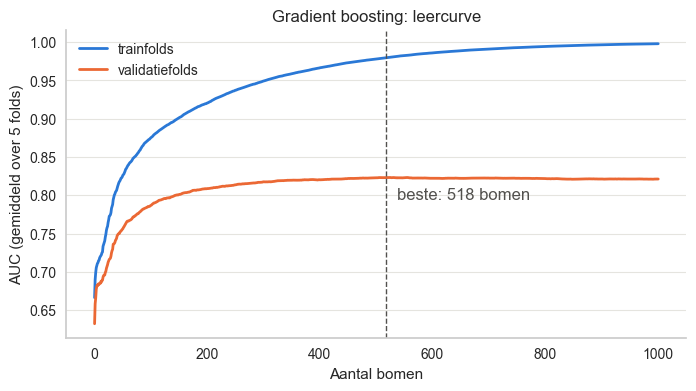

In [9]:
gbc_search = GridSearchCV(
    make_model(GradientBoostingClassifier(n_estimators=300, random_state=SEED)),
    param_grid={
        "gradientboostingclassifier__learning_rate": [0.03, 0.1],
        "gradientboostingclassifier__max_depth": [3, 5],
        "gradientboostingclassifier__subsample": [0.8, 1.0],
    },
    scoring="roc_auc", cv=cv, n_jobs=-1,
).fit(X_train, y_train)
print("Beste instellingen:", gbc_search.best_params_, f"| CV AUC {gbc_search.best_score_:.3f}")

# Leercurve: AUC na 1, 2, ..., 1000 bomen, gemiddeld over dezelfde 5 folds
N_TREES = 1000
curve_model = clone(gbc_search.best_estimator_).set_params(gradientboostingclassifier__n_estimators=N_TREES)
train_auc, val_auc = [], []
for train_idx, val_idx in cv.split(X_train, y_train):
    fitted = clone(curve_model).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    preprocess, booster = fitted[:-1], fitted[-1]
    for idx, store in [(train_idx, train_auc), (val_idx, val_auc)]:
        X_part = preprocess.transform(X_train.iloc[idx])
        store.append([roc_auc_score(y_train.iloc[idx], p[:, 1]) for p in booster.staged_predict_proba(X_part)])
curve = pd.DataFrame({"train": np.mean(train_auc, axis=0), "validatie": np.mean(val_auc, axis=0)},
                     index=range(1, N_TREES + 1))
best_n_trees = int(curve["validatie"].idxmax())
print(f"Beste aantal bomen: {best_n_trees} (CV AUC {curve['validatie'].max():.3f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve.index, curve["train"], color="#2a78d6", linewidth=2, label="trainfolds")
ax.plot(curve.index, curve["validatie"], color="#eb6834", linewidth=2, label="validatiefolds")
ax.axvline(best_n_trees, color="#52514e", linestyle="--", linewidth=1)
ax.annotate(f"beste: {best_n_trees} bomen", (best_n_trees, curve["validatie"].max()), xytext=(8, -16),
            textcoords="offset points", color="#52514e")
ax.set_xlabel("Aantal bomen")
ax.set_ylabel("AUC (gemiddeld over 5 folds)")
ax.set_title("Gradient boosting: leercurve")
ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
ax.grid(axis="x", visible=False)  # PyCaret zet een stijl met rasterlijnen
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

**XGBoost** (zoals in `5.4`) is een snellere, sterker geregulariseerde versie van gradient boosting. Het kan zelf met NaN omgaan, dus de numerieke kolommen krijgen geen imputer. Er zijn veel hyperparameters, dus we doen een **random search van 40 combinaties** over een zoekruimte zoals in `5.4`, aangevuld met extra regularisatie (`min_child_weight`, `reg_lambda`).

In [10]:
xgb_search = RandomizedSearchCV(
    make_model(XGBClassifier(eval_metric="logloss", random_state=SEED, n_jobs=-1), num_step="passthrough",
               cat_step=OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    param_distributions={
        "xgbclassifier__n_estimators": [100, 200, 400, 800],
        "xgbclassifier__max_depth": [2, 3, 4, 5, 7],
        "xgbclassifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "xgbclassifier__subsample": [0.6, 0.8, 1.0],
        "xgbclassifier__colsample_bytree": [0.4, 0.6, 0.8, 1.0],
        "xgbclassifier__min_child_weight": [1, 3, 5, 10],
        "xgbclassifier__gamma": [0, 0.1, 0.5, 1],
        "xgbclassifier__reg_lambda": [1, 5, 10],
    },
    n_iter=40, scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=1,
).fit(X_train, y_train)
print("Beste instellingen:", {k.split("__")[1]: v for k, v in xgb_search.best_params_.items()})

BOOSTING = {
    "Gradient boosting (getuned)": clone(gbc_search.best_estimator_).set_params(
        gradientboostingclassifier__n_estimators=best_n_trees),
    "XGBoost (getuned)": xgb_search.best_estimator_,
}
for name, model in BOOSTING.items():
    results.loc[name] = cv_scores(model, label=name)
results.loc[["Random forest (getuned)", *BOOSTING]].round(3)

Beste instellingen: {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}


,CV AUC,CV accuracy,CV recall giftig,CV AP,CV AUC std,train accuracy
Random forest (getuned),0.836,0.799,0.596,0.786,0.015,0.960
Gradient boosting (getuned),0.823,0.791,0.585,0.765,0.013,0.910
XGBoost (getuned),0.817,0.785,0.566,0.758,0.016,0.876


**Interpretatie:**
- De leercurve toont het patroon uit `5.3`: op de trainfolds stijgt de AUC tot bijna 1 (het model leert de trainset, inclusief de omgedraaide labels, uit het hoofd), maar op de validatiefolds stopt de winst rond 500 bomen (AUC 0,823) en blijft ze daarna vlak. Extra bomen vergroten enkel de kloof tussen train en validatie.
- Beide boosting-modellen scoren **lager** dan de random forest: gradient boosting 0,823 en XGBoost 0,817, tegenover 0,836. Dat past bij de theorie: boosting focust op de rijen die het fout heeft, en bij ±8% omgedraaide labels (stap 8b) zijn dat net de foute labels. Bagging middelt die ruis gewoon uit.
- XGBoost kiest diepe bomen (`max_depth=7`), maar ook dan is er niet meer signaal te halen.

### 4c. Stacking: modellen combineren

Bij stacking (zoals in `5.5` en `6`) leert een **meta-model** (hier een logistische regressie) hoe het de voorspellingen van meerdere **basismodellen** best combineert. Scikit-learn's `StackingClassifier` traint het meta-model op **out-of-fold** voorspellingen van de basismodellen, zodat het meta-model niet leert van voorspellingen op rijen die de basismodellen al gezien hebben.

Stacking werkt enkel als de basismodellen **verschillende fouten** maken. We kijken daarom eerst hoe sterk hun voorspellingen samenhangen. Als basismodellen nemen we onze beste modellen, aangevuld met twee modellen die heel anders werken: **KNN** (afstanden) en **logistische regressie** (lineair). Die twee hebben geschaalde numerieke kolommen nodig.

In [11]:
scaled_numeric = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
knn_search = GridSearchCV(
    make_model(KNeighborsClassifier(), num_step=scaled_numeric),
    param_grid={"kneighborsclassifier__n_neighbors": [15, 30, 50, 80],
                "kneighborsclassifier__weights": ["uniform", "distance"]},
    scoring="roc_auc", cv=cv, n_jobs=-1,
).fit(X_train, y_train)

BASE_MODELS = {
    "rf": TUNED["Random forest (getuned)"],
    "xgb": BOOSTING["XGBoost (getuned)"],
    "gb": BOOSTING["Gradient boosting (getuned)"],
    "dt": TUNED["Decision tree (getuned)"],
    "knn": knn_search.best_estimator_,
    "lr": make_model(LogisticRegression(max_iter=2000), num_step=scaled_numeric),
}
base_oof = pd.DataFrame({name: cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
                         for name, model in BASE_MODELS.items()})
print("CV AUC per basismodel:", base_oof.apply(lambda p: round(roc_auc_score(y_train, p), 3)).to_dict())
print("\nCorrelatie tussen de voorspelde kansen (1 = altijd dezelfde mening):")
base_oof.corr().round(2)

CV AUC per basismodel: {'rf': 0.835, 'xgb': 0.817, 'gb': 0.823, 'dt': 0.772, 'knn': 0.784, 'lr': 0.694}

Correlatie tussen de voorspelde kansen (1 = altijd dezelfde mening):


,rf,xgb,gb,dt,knn,lr
rf,1.00,0.92,0.94,0.79,0.82,0.63
xgb,0.92,1.00,0.94,0.76,0.74,0.67
gb,0.94,0.94,1.00,0.78,0.76,0.67
dt,0.79,0.76,0.78,1.00,0.62,0.55
knn,0.82,0.74,0.76,0.62,1.00,0.53
lr,0.63,0.67,0.67,0.55,0.53,1.00


In [12]:
def stack(names):
    return StackingClassifier([(n, BASE_MODELS[n]) for n in names], final_estimator=LogisticRegression(max_iter=1000),
                              stack_method="predict_proba", cv=5)


ENSEMBLES = {
    "Voting RF + XGB (gemiddelde kans)": VotingClassifier([(n, BASE_MODELS[n]) for n in ["rf", "xgb"]], voting="soft"),
    "Stacking RF + XGB": stack(["rf", "xgb"]),
    "Stacking RF + XGB + KNN + LR": stack(["rf", "xgb", "knn", "lr"]),
    "Stacking alle 6 modellen": stack(list(BASE_MODELS)),
}
for name, model in ENSEMBLES.items():
    results.loc[name] = cv_scores(model, label=name)
results.loc[["Random forest (getuned)", *ENSEMBLES]].round(3)

,CV AUC,CV accuracy,CV recall giftig,CV AP,CV AUC std,train accuracy
Random forest (getuned),0.836,0.799,0.596,0.786,0.015,0.960
Voting RF + XGB (gemiddelde kans),0.833,0.796,0.581,0.780,0.016,0.921
Stacking RF + XGB,0.836,0.806,0.629,0.786,0.015,0.958
Stacking RF + XGB + KNN + LR,0.835,0.804,0.637,0.784,0.015,0.984
Stacking alle 6 modellen,0.835,0.806,0.637,0.782,0.015,0.985


**Interpretatie:**
- De voorspellingen van RF, XGBoost en gradient boosting zijn voor **0,92–0,94 gecorreleerd**: ze maken grotendeels **dezelfde fouten**. Een meta-model kan dan niets bijleren, want waar de ene het mis heeft, heeft de andere het ook mis.
- De modellen die wél anders denken (decision tree, KNN, logistische regressie, correlatie 0,53–0,82) zijn duidelijk **zwakker** (AUC 0,69–0,78). Ze toevoegen verandert niets: 0,836 met RF + XGB, 0,835 met alle 6 modellen.
- **Resultaat:** stacking en voting komen op dezelfde AUC als de random forest alleen (0,833–0,836 tegenover 0,836), ver binnen de spreiding tussen de folds. In `5.5` werkte stacking wel, omdat de basismodellen daar elk een ander deel van een propere, niet-lineaire curve goed hadden. Hier botsen alle modellen tegen dezelfde muur: de ruis in de data.
- Opvallend: bij drempel 0,5 hebben de stacking-modellen een hogere recall (0,63–0,64 tegenover 0,60). Dat komt doordat het meta-model de kansen anders schaalt, niet doordat het giftig en eetbaar beter scheidt: de AUC is gelijk. Met onze eigen drempel (stap 5) valt dat verschil weg.
- Een complexer model zonder winst is een slechter model (trager, moeilijker uit te leggen, groter bestand). We houden dus de random forest.

### 4d. Andere preprocessing en labelruis

Misschien zit de winst niet in het model maar in **wat we het model geven**. We testen ingrepen op de data en de preprocessing, telkens met dezelfde 5 folds en dezelfde instellingen als de getunede random forest:

| Variant | Idee |
|---|---|
| Ordinal-encoding | Eén kolom per kenmerk i.p.v. één per categorie: een boom kan dan meerdere categorieën in één splitsing groeperen. |
| Extra kenmerken | Bomen kunnen geen verhoudingen berekenen. We voegen hoed/steel-verhoudingen en het aantal ontbrekende kenmerken toe. |
| "Ontbreekt"-kolommen | Een 0/1-kolom per numeriek kenmerk dat ingevuld werd door de imputer. |
| Geen imputatie | Sinds scikit-learn 1.4 kan een random forest zelf met NaN omgaan. |
| Verdachte labels weglaten | Binnen elke trainfold: rijen waar het model heel zeker het tegenovergestelde voorspelt (kans < 0,15 of > 0,85) zijn waarschijnlijk omgedraaid. We trainen opnieuw zonder die rijen. De validatiefold blijft onaangeroerd. |
| HistGradientBoosting met eigen categorieën | Boosting die categorieën zelf kan splitsen, zonder one-hot encoding, en zelf met NaN omgaat. |

In [13]:
rf_best = rf_search.best_estimator_[-1]  # het getunede RandomForestClassifier-object


def add_features(X):
    X = X.copy()
    X["cap_stem_ratio"] = X["cap_diameter_cm"] * 10 / (X["stem_width_mm"] + 1)    # hoed t.o.v. steel (beide in mm)
    X["stem_slenderness"] = X["stem_height_cm"] * 10 / (X["stem_width_mm"] + 1)   # lange, dunne steel?
    X["n_missing"] = X[NUMERIC].isna().sum(axis=1) + X[CATEGORICAL].eq("unknown").sum(axis=1)
    return X


class DropSuspiciousLabels(ClassifierMixin, BaseEstimator):
    """Train het model, gooi trainrijen weg waarvan het label sterk tegenspreekt wat een out-of-fold model
    voorspelt, en train opnieuw. Enkel de TRAININGSlabels worden aangeraakt."""

    def __init__(self, model, cut=0.15):
        self.model, self.cut = model, cut

    def fit(self, X, y):
        y = np.asarray(y)
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
        proba = cross_val_predict(clone(self.model), X, y, cv=inner_cv, method="predict_proba")[:, 1]
        suspicious = ((y == 1) & (proba < self.cut)) | ((y == 0) & (proba > 1 - self.cut))
        self.model_ = clone(self.model).fit(X[~suspicious], y[~suspicious])
        self.classes_ = self.model_.classes_
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

    def predict(self, X):
        return self.model_.predict(X)


ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
ALTERNATIVES = {
    "RF ordinal-encoding": make_model(clone(rf_best), cat_step=ordinal),
    "RF + extra kenmerken": make_model(clone(rf_best), numeric=NUMERIC + ["cap_stem_ratio", "stem_slenderness", "n_missing"],
                                       features=FunctionTransformer(add_features)),
    "RF + 'ontbreekt'-kolommen": make_model(clone(rf_best), num_step=SimpleImputer(strategy="median", add_indicator=True)),
    "RF zonder imputatie (NaN zelf)": make_model(clone(rf_best), num_step="passthrough",  # NaN-support vraagt een dense matrix
                                                 cat_step=OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    "RF + verdachte labels weglaten": DropSuspiciousLabels(make_model(clone(rf_best))),
    "HistGradientBoosting (eigen categorieën)": make_model(
        HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, min_samples_leaf=10, l2_regularization=1.0,
                                       categorical_features=[False] * len(NUMERIC) + [True] * len(CATEGORICAL),
                                       random_state=SEED),
        num_step="passthrough", cat_step=ordinal),
}
for name, model in ALTERNATIVES.items():
    results.loc[name] = cv_scores(model, label=name)
results.loc[["Random forest (getuned)", *ALTERNATIVES]].round(3)

,CV AUC,CV accuracy,CV recall giftig,CV AP,CV AUC std,train accuracy
Random forest (getuned),0.836,0.799,0.596,0.786,0.015,0.960
RF ordinal-encoding,0.829,0.794,0.582,0.775,0.011,0.964
RF + extra kenmerken,0.834,0.802,0.606,0.783,0.016,0.973
RF + 'ontbreekt'-kolommen,0.837,0.800,0.594,0.785,0.013,0.963
RF zonder imputatie (NaN zelf),0.836,0.798,0.589,0.786,0.013,0.966
RF + verdachte labels weglaten,0.836,0.798,0.590,0.785,0.015,0.954
HistGradientBoosting (eigen categorieën),0.823,0.795,0.631,0.768,0.016,0.965


**Interpretatie:**
- Geen enkele variant doet duidelijk beter dan de getunede random forest. De verschillen zijn kleiner dan de spreiding tussen de folds (std ±0,015).
- Extra kenmerken en "ontbreekt"-kolommen voegen niets toe. De verhoudingen kan het forest blijkbaar al benaderen met gewone splitsingen, en de gaten zijn willekeurig (zie `01`).
- Verdachte labels weglaten helpt ook niet. Het forest middelt de omgedraaide labels al uit, en de validatiefolds bevatten zelf ook omgedraaide labels, die we niet kunnen verbeteren.
- Ordinal-encoding en de categorieën van HistGradientBoosting doen het iets slechter dan one-hot encoding.

### 4e. Klopten de cleaningkeuzes uit `01`? (ablatie)

In `01` maakten we keuzes op basis van redeneringen en statistische toetsen. De opdracht vraagt ook om na te gaan of die keuzes **het model echt helpen**. Daarom draaien we telkens één keuze terug en meten we het effect, met dezelfde random forest en dezelfde 5 folds (een *ablatiestudie*):

| Variant | Keuze in `01` die we terugdraaien |
|---|---|
| Ruiskolommen behouden | Stap 3: `jumbled_noise_0/1` verwijderd |
| Geen steel-reconstructie | Stap 6c: 18 ontbrekende steelwaarden logisch afgeleid (0 / none) |
| Modus i.p.v. `"unknown"` | Stap 6d: ontbrekende categorieën als eigen categorie |
| `spore_print_color` verwijderen | Stap 6d: kolom behouden ondanks 95% ontbrekend |
| Uitschieters clippen | Stap 7: geen clipping (grenzen per trainfold geleerd, geen leakage) |

In [14]:
class IQRClipper(BaseEstimator, TransformerMixin):
    """Knipt numerieke waarden af op Q1 - 1,5*IQR en Q3 + 1,5*IQR, met grenzen geleerd op de trainfold."""

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        self.low_, self.high_ = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.low_, self.high_)


def to_object(X):
    return X.astype(object)  # SimpleImputer werkt niet rechtstreeks op pandas-categorieën


# Ruwe kolommen terughalen via het id (= rijnummer in het ruwe bestand, zie 01)
raw = pd.read_csv("data/raw/mushroom_project_dataset.csv").loc[df["id"]].set_index(df.index)
NOISE_COLS = ["jumbled_noise_0", "jumbled_noise_1"]
X_with_noise = X.assign(**{c: raw[c].fillna("unknown").astype("category") for c in NOISE_COLS})
X_no_stem_fix = X.copy()
X_no_stem_fix.loc[raw["stem-height"].isna(), "stem_height_cm"] = np.nan
X_no_stem_fix.loc[raw["stem-width"].isna(), "stem_width_mm"] = np.nan
X_no_stem_fix.loc[raw["stem-surface"].isna(), "stem_surface"] = "unknown"

ABLATIONS = {
    "Cleaning: ruiskolommen behouden": (
        make_model(clone(rf_best), categorical=CATEGORICAL + NOISE_COLS), X_with_noise),
    "Cleaning: geen steel-reconstructie": (make_model(clone(rf_best)), X_no_stem_fix),
    "Cleaning: modus i.p.v. 'unknown'": (
        make_model(clone(rf_best), cat_step=make_pipeline(FunctionTransformer(to_object),
                                                          SimpleImputer(missing_values="unknown", strategy="most_frequent"),
                                                          OneHotEncoder(handle_unknown="ignore"))), X),
    "Cleaning: spore_print_color verwijderen": (
        make_model(clone(rf_best), categorical=[c for c in CATEGORICAL if c != "spore_print_color"]), X),
    "Cleaning: uitschieters clippen": (
        make_model(clone(rf_best), num_step=make_pipeline(IQRClipper(), SimpleImputer(strategy="median"))), X),
}
for name, (model, X_variant) in ABLATIONS.items():
    results.loc[name] = cv_scores(model, label=name, X=X_variant[~is_test])

ablation_names = ["Random forest (getuned)", *ABLATIONS]
results.loc[ablation_names, ["CV AUC", "CV AP", "CV AUC std"]].join(paired(ablation_names)).round(4)

,CV AUC,CV AP,CV AUC std,verschil AUC met RF,spreiding verschil,folds beter dan RF
Random forest (getuned),0.8360,0.7861,0.0147,0.0000,0.0000,0
Cleaning: ruiskolommen behouden,0.8332,0.7809,0.0137,-0.0028,0.0022,1
Cleaning: geen steel-reconstructie,0.8363,0.7853,0.0136,0.0003,0.0029,3
Cleaning: modus i.p.v. 'unknown',0.8244,0.7764,0.0111,-0.0116,0.0104,1
Cleaning: spore_print_color verwijderen,0.8346,0.7828,0.0147,-0.0014,0.0018,2
Cleaning: uitschieters clippen,0.8354,0.7851,0.0136,-0.0006,0.0015,1


**Interpretatie:**
- **Elke keuze uit `01` wordt bevestigd**: geen enkele teruggedraaide keuze doet beter dan de huidige cleaning.
- **`"unknown"` als eigen categorie** is de belangrijkste keuze: met de modus invullen kost gemiddeld 0,012 AUC. De modus verzint een kenmerk, en het signaal "niet beschreven" (informatief bij `stem_surface` en `spore_print_color`, zie `01` stap 6b) gaat verloren.
- **De ruiskolommen verwijderen** helpt ook (behouden kost 0,003, en is in 4 van de 5 folds slechter). Een random forest kiest af en toe een splitsing op pure ruis, en dat kost een beetje.
- `spore_print_color` behouden (+0,001) en niet clippen (+0,001) helpen een beetje. De steel-reconstructie maakt geen verschil (±0,000): het gaat maar om 18 waarden. Die keuze was vooral logisch correct, niet nodig voor het model.
- Kijk naar de kolom **folds beter dan RF**: geen enkele variant wint in een meerderheid van de folds met een duidelijke marge. De verschillen van ±0,001 zijn ruis, die van 0,003 en 0,012 zijn consistent.

### 4f. Overzicht: alle modellen naast elkaar

Alle scores komen van **dezelfde 5 folds** op de trainset. Bij onze eigen modellen tonen we ook de spreiding tussen de folds (± 1 standaardafwijking). Omdat alle modellen op **exact dezelfde folds** getest zijn, vergelijken we ook **fold per fold** met de random forest (gepaarde vergelijking). Dat is veel gevoeliger dan twee gemiddelden naast elkaar zetten: een moeilijke fold is moeilijk voor elk model, en die schommeling valt weg in het verschil. Een model dat echt beter is, scoort in (bijna) **alle 5 folds** beter.

In [15]:
GROUPS = {
    "Decision tree (getuned)": "1–3 decision tree / random forest", "Random forest (getuned)": "1–3 decision tree / random forest",
    **{name: "4b boosting" for name in BOOSTING}, **{name: "4c stacking / voting" for name in ENSEMBLES},
    **{name: "4d preprocessing / labelruis" for name in ALTERNATIVES},
    **{name: "4e cleaningkeuzes uit 01" for name in ABLATIONS},
}
ours = (results.loc[list(GROUPS)].assign(groep=pd.Series(GROUPS))[["groep", "CV AUC", "CV AUC std", "CV AP"]]
        .join(paired(list(GROUPS))))
pycaret_rows = (pycaret_comparison[~pycaret_comparison.index.isin(["dummy"])]
                .set_index("Model")[["AUC"]].rename(columns={"AUC": "CV AUC"})
                .rename(index=lambda name: f"PyCaret: {name}").assign(groep="4a PyCaret (standaard)"))
overview = pd.concat([ours, pycaret_rows]).sort_values("CV AUC", ascending=False)
overview.round(3)

,groep,CV AUC,CV AUC std,CV AP,verschil AUC met RF,spreiding verschil,folds beter dan RF
RF + 'ontbreekt'-kolommen,4d preprocessing / labelruis,0.837,0.013,0.785,0.001,0.003,3.0
RF zonder imputatie (NaN zelf),4d preprocessing / labelruis,0.836,0.013,0.786,0.000,0.004,2.0
Cleaning: geen steel-reconstructie,4e cleaningkeuzes uit 01,0.836,0.014,0.785,0.000,0.003,3.0
Stacking RF + XGB,4c stacking / voting,0.836,0.015,0.786,0.000,0.001,2.0
RF + verdachte labels weglaten,4d preprocessing / labelruis,0.836,0.015,0.785,0.000,0.003,3.0
Random forest (getuned),1–3 decision tree / random forest,0.836,0.015,0.786,0.000,0.000,0.0
Stacking RF + XGB + KNN + LR,4c stacking / voting,0.835,0.015,0.784,-0.001,0.002,3.0
Cleaning: uitschieters clippen,4e cleaningkeuzes uit 01,0.835,0.014,0.785,-0.001,0.002,1.0
Stacking alle 6 modellen,4c stacking / voting,0.835,0.015,0.782,-0.001,0.002,2.0
Cleaning: spore_print_color verwijderen,4e cleaningkeuzes uit 01,0.835,0.015,0.783,-0.001,0.002,2.0


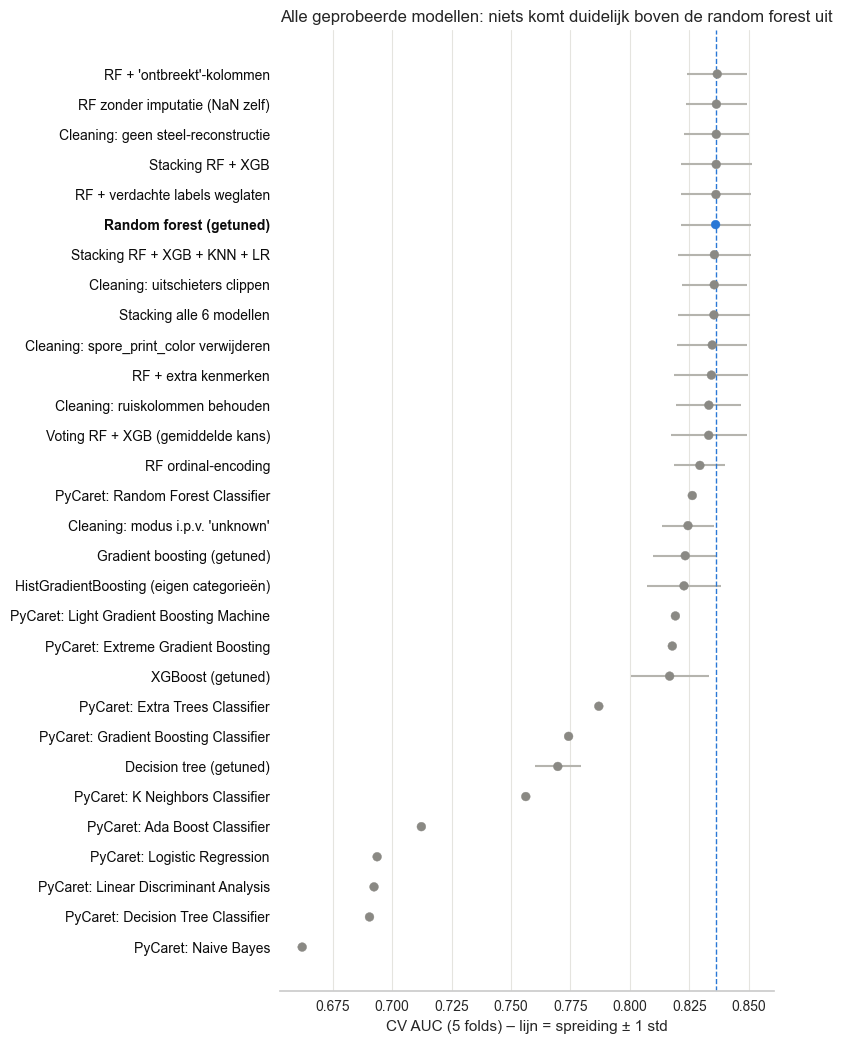

In [16]:
chosen = "Random forest (getuned)"
plot_data = overview[overview["CV AUC"] >= 0.65].sort_values("CV AUC")  # zwakste PyCaret-modellen weggelaten
colors = ["#2a78d6" if name == chosen else "#8a8984" for name in plot_data.index]

fig, ax = plt.subplots(figsize=(8, 0.32 * len(plot_data) + 1))
ax.errorbar(plot_data["CV AUC"], range(len(plot_data)), xerr=plot_data["CV AUC std"].fillna(0), fmt="none",
            ecolor="#b5b4ae", elinewidth=1.5, capsize=0)
ax.scatter(plot_data["CV AUC"], range(len(plot_data)), c=colors, s=40, zorder=3)
ax.axvline(overview.loc[chosen, "CV AUC"], color="#2a78d6", linewidth=1, linestyle="--")
ax.set_yticks(range(len(plot_data)), plot_data.index, color="#0b0b0b")
for tick, name in zip(ax.get_yticklabels(), plot_data.index):
    tick.set_fontweight("bold" if name == chosen else "normal")
ax.set_xlabel("CV AUC (5 folds) – lijn = spreiding ± 1 std")
ax.set_title("Alle geprobeerde modellen: niets komt duidelijk boven de random forest uit", loc="left")
ax.grid(axis="x", color="#e5e4df", linewidth=0.8)
ax.grid(axis="y", visible=False)  # PyCaret zet een stijl met rasterlijnen
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

**Wat zegt de gepaarde vergelijking?** Geen enkel alternatief is in alle 5 folds beter dan de random forest. De "beste" alternatieven ("ontbreekt"-kolommen, stacking, labels opkuisen: ±0,000 tot +0,001) winnen in 2 à 3 van de 5 folds: dat is wat je bij toeval verwacht. Boosting, XGBoost, ordinal-encoding en de decision tree verliezen in **alle 5** folds: die zijn echt slechter.

**Waarom wordt het niet beter?** Drie redenen, die elkaar versterken:

1. **Alle sterke modellen zijn het met elkaar eens** (correlatie 0,92–0,94, stap 4c). Ze vinden dezelfde patronen en missen dezelfde paddenstoelen. Een ander of gecombineerd model kan dus niets nieuws ontdekken.
2. **Labelruis.** Ongeveer 1 op 12 labels is omgedraaid (bewezen en geschat in stap 8b), ook in de validatiefolds en de testset. Zelfs een perfect model zou op de testset maar een AUC van ±0,91 meten (stap 8d). Een model dat zo'n rij "juist" voorspelt, wordt toch fout gerekend. Boosting maakt het zelfs erger, omdat het extra aandacht geeft aan net die rijen.
3. **Ontbrekende informatie.** Bijna elke paddenstoel mist kenmerken. Met weinig gaten haalt de random forest AUC 0,88, met veel gaten maar 0,76 (stap 8c). Geen enkel model kan informatie gebruiken die er niet is.

**Conclusie van stap 4:** de random forest zit aan het **plafond van de data**, niet van het model. We houden de getunede random forest (en de decision tree als uitlegbaar alternatief). Verdere winst zit in **hoe we de kans gebruiken** (stap 5) en in **betere invoer** in de webapp (stap 8c).

## 5. Drempelwaarde kiezen (threshold tuning)

Standaard zegt een model "giftig" als de kans ≥ 0,5. Voor ons is een gemiste giftige paddenstoel veel erger dan een onterecht weggegooide eetbare. Daarom verlagen we de drempel (zie `3 model quality/2 - Threshold tuning.ipynb`).

**Waar kiezen we de drempel op?** **Niet op de testset**, want dan tunen we op de test. We maken **out-of-fold voorspellingen** op de trainset: elke rij wordt voorspeld door een model dat die rij niet gezien heeft (`cross_val_predict`).

**Regel:** de **hoogste drempel waarbij de recall op giftig ≥ 90%** is. Hoe hoger de drempel, hoe minder eetbare paddenstoelen we onterecht weggooien.

We proberen daarbij **elke voorspelde kans** als drempel, niet enkel een raster van 0,05, 0,10, … Een grof raster kiest bijna altijd een te lage drempel (en gooit dus onnodig eetbare paddenstoelen weg). Als de recall bij geen enkele drempel gehaald wordt, geeft de functie een **foutmelding** in plaats van stilletjes de laagste drempel te kiezen.

> Waarom 90% en niet 99%? Een deel van de "giftig"-labels is waarschijnlijk een omgedraaide eetbare paddenstoel (zie `01`). Die ziet er voor het model eetbaar uit. Een recall van ±100% kan dan enkel door bijna **alles** giftig te noemen, en dan is het model nutteloos.

In [17]:
def evaluate_threshold(y_true, proba, threshold):
    tn, fp, fn, tp = confusion_matrix(y_true, (proba >= threshold).astype(int)).ravel()
    return {"threshold": threshold, "recall giftig": tp / (tp + fn), "specificity (eetbaar herkend)": tn / (tn + fp),
            "accuracy": (tp + tn) / len(y_true), "gemiste giftige (FN)": fn, "onterecht giftig (FP)": fp}


oof_proba = {name: cross_val_predict(clone(model), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
             for name, model in TUNED.items()}

THRESHOLDS = np.arange(0.05, 0.96, 0.05).round(2)
threshold_table = pd.DataFrame([evaluate_threshold(y_train, oof_proba["Random forest (getuned)"], t) for t in THRESHOLDS])
threshold_table.round(3)

,threshold,recall giftig,specificity (eetbaar herkend),accuracy,gemiste giftige (FN),onterecht giftig (FP)
0,0.05,0.993,0.027,0.392,11,2420
1,0.10,0.979,0.130,0.451,32,2163
2,0.15,0.946,0.253,0.515,82,1858
3,0.20,0.911,0.403,0.595,135,1485
4,0.25,0.859,0.545,0.664,214,1132
5,0.30,0.814,0.671,0.725,281,819
6,0.35,0.776,0.771,0.773,339,569
7,0.40,0.718,0.844,0.796,427,387
8,0.45,0.653,0.895,0.803,525,262
9,0.50,0.596,0.923,0.799,611,192


In [18]:
MIN_RECALL = 0.90


def choose_threshold(y_true, proba, min_recall=MIN_RECALL):
    """Hoogste drempel met recall giftig >= min_recall. Elke voorspelde kans is een kandidaat-drempel."""
    y_true = np.asarray(y_true)
    for t in np.sort(np.unique(proba))[::-1]:
        if (proba[y_true == 1] >= t).mean() >= min_recall:
            return float(np.floor(t * 1000) / 1000)  # naar beneden afronden: de recall blijft >= min_recall
    raise ValueError(f"Een recall van {min_recall:.0%} is bij geen enkele drempel haalbaar")


THRESHOLD = {name: choose_threshold(y_train, proba) for name, proba in oof_proba.items()}
pd.DataFrame({name: evaluate_threshold(y_train, oof_proba[name], t) for name, t in THRESHOLD.items()}).T.round(3)

,threshold,recall giftig,specificity (eetbaar herkend),accuracy,gemiste giftige (FN),onterecht giftig (FP)
Decision tree (getuned),0.163,0.901,0.338,0.551,150.0,1646.0
Random forest (getuned),0.211,0.900,0.435,0.611,151.0,1404.0


**Interpretatie:**
- Voor de random forest is **0,211** de hoogste drempel met ≥ 90% recall. De prijs: meer dan de helft van de eetbare paddenstoelen wordt dan "giftig" genoemd (specificity 43,5%).
- Met het grove raster van 0,05 (tabel hierboven) zouden we 0,20 kiezen: recall 91,1% maar specificity 40,3%. De fijne drempel geeft precies de gevraagde 90% en gooit zo ±80 eetbare trainrijen minder onterecht weg.
- Voor de decision tree is de drempel **0,163**. Een boom geeft maar een beperkt aantal verschillende kansen (één per blad), dus de drempel springt van blad naar blad.
- In onze eerste versie (onbeperkte boom, `min_samples_leaf=10`) was 90% recall bij **geen enkele** drempel haalbaar, en koos de code stilletjes de laagste drempel uit het raster (0,05). Die boom scoorde op de testset toevallig 92% recall, maar dat was niet op de trainset onderbouwd. Daarom geeft `choose_threshold` nu een foutmelding als de recall niet haalbaar is.

> 💬 *Teamkeuze:* de drempel is een beleidsbeslissing, geen technische. Wij kiezen voor veiligheid. De webapp moet sowieso duidelijk tonen dat dit **geen** betrouwbaar eetadvies is.

### 5b. Een derde zone: "onzeker"

Met één drempel zijn er maar twee antwoorden. Alles onder 0,2 heet "eetbaar", ook een paddenstoel met kans 0,19, waar het model eigenlijk twijfelt. Voor een app is het eerlijker om drie antwoorden te geven:

| Zone | Kans op giftig | Advies |
|---|---|---|
| **eetbaar** | < veilige drempel | het model is zeker genoeg |
| **onzeker** | tussen beide drempels | waarschijnlijk eetbaar, maar niet zeker genoeg → niet eten |
| **giftig** | ≥ drempel uit stap 5 | niet eten |

De **veilige drempel** kiezen we met dezelfde functie, maar strenger: maximaal 2% van de giftige paddenstoelen mag in de zone "eetbaar" terechtkomen (recall ≥ 98%). Weer op de out-of-fold voorspellingen, niet op de testset.

We doen dit enkel voor de random forest. De decision tree geeft maar een handvol verschillende kansen (één per blad) en is daar te grof voor.

In [19]:
best_name = "Random forest (getuned)"
MIN_RECALL_SAFE = 0.98
SAFE_THRESHOLD = choose_threshold(y_train, oof_proba[best_name], MIN_RECALL_SAFE)
ZONES = ["eetbaar", "onzeker", "giftig"]


def zone(proba, safe=SAFE_THRESHOLD, threshold=THRESHOLD[best_name]):
    return np.select([proba < safe, proba < threshold], ["eetbaar", "onzeker"], "giftig")


def zone_table(y_true, proba):
    zones = pd.DataFrame({"zone": zone(proba), "giftig": np.asarray(y_true)})
    table = zones.groupby("zone")["giftig"].agg(aantal="size", gelabeld_giftig="sum").reindex(ZONES)
    table["aandeel van alle paddenstoelen"] = table["aantal"] / table["aantal"].sum()
    table["% gelabeld giftig"] = table["gelabeld_giftig"] / table["aantal"]
    return table


print(f"veilige drempel: {SAFE_THRESHOLD} | drempel giftig: {THRESHOLD[best_name]}")
zone_table(y_train, oof_proba[best_name]).round(3)

veilige drempel: 0.096 | drempel giftig: 0.211


,aantal,gelabeld_giftig,aandeel van alle paddenstoelen,% gelabeld giftig
zone,,,,
eetbaar,320,29,0.080,0.091
onzeker,913,122,0.228,0.134
giftig,2767,1363,0.692,0.493


**Interpretatie:**
- De veilige drempel is **0,096**. Slechts **8%** van de paddenstoelen krijgt dan "eetbaar", maar daar is het model het zekerst.
- Toch heeft ook in die zone nog **9%** het label giftig. Lager krijgen we het niet, ook niet met een nog lagere drempel. In stap 8b zien we waarom: dat is ongeveer het percentage omgedraaide labels.
- In de zone "onzeker" (23%) heeft 13% het label giftig. Met één drempel zouden die allemaal "eetbaar" heten. Nu weet de gebruiker dat het model twijfelt.
- Voor de beslissing "eten of niet" verandert er niets ten opzichte van één drempel ("onzeker" = niet eten). Wat wel verandert: de app is **eerlijker** over hoe zeker het model is.

### 5c. Kunnen we beide drempels combineren?

Drempel 0,5 geeft de hoogste accuracy, drempel 0,211 vangt de meeste giftige paddenstoelen. Een voor de hand liggend idee: laat **beide drempels** een voorspelling maken, en test enkel de gevallen waar ze het **oneens** zijn nog eens opnieuw. Zo zouden we het beste van beide nemen, zoals bij medische screening (eerst een snelle test, de twijfelgevallen naar een tweede test).

We testen dat in twee stappen:
1. **Twee drempels op hetzelfde model.** Welke groepen ontstaan er?
2. **Een tweede model voor de twijfelgevallen** (een *cascade*). Een "specialist" die enkel getraind is op de paddenstoelen waar de random forest twijfelt. Kan die ze beter uit elkaar houden?

In [20]:
p_oof = oof_proba[best_name]
LOW, HIGH = THRESHOLD[best_name], 0.5
both = pd.Series(np.select([p_oof >= HIGH, p_oof >= LOW], ["beide zeggen giftig", "oneens"], "beide zeggen eetbaar"),
                 index=y_train.index, name="groep")
(pd.DataFrame({"rijen": both.value_counts(), "% gelabeld giftig": y_train.groupby(both).mean()})
 .reindex(["beide zeggen giftig", "oneens", "beide zeggen eetbaar"]).round(3))

,rijen,% gelabeld giftig
groep,,
beide zeggen giftig,1095,0.825
oneens,1672,0.275
beide zeggen eetbaar,1233,0.122


**Stap 2: de cascade.** Eerlijk testen vraagt **geneste** cross-validation: in elke buitenste fold zoeken we eerst out-of-fold welke **trainrijen** in de twijfelzone vallen, trainen we de specialist enkel op die rijen, en beoordelen we hem op de twijfelgevallen van de validatiefold. We vergelijken met de gewone random forest op exact dezelfde twijfelgevallen.

In [21]:
def in_doubt(proba):
    return (proba >= LOW) & (proba < HIGH)


SPECIALISTS = {
    "Specialist random forest": make_model(clone(rf_best).set_params(min_samples_leaf=5)),
    "Specialist boosting": clone(ALTERNATIVES["HistGradientBoosting (eigen categorieën)"]),
}
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 3)
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 4)
cascade = pd.DataFrame(index=y_train.index, columns=["Random forest (stap 1)", *SPECIALISTS], dtype=float)
for tr, te in outer.split(X_train, y_train):
    X_tr, y_tr, X_te = X_train.iloc[tr], y_train.iloc[tr], X_train.iloc[te]
    # Stap 1: welke trainrijen vallen (out-of-fold) in de twijfelzone, en welke validatierijen?
    doubt_tr = in_doubt(cross_val_predict(clone(TUNED[best_name]), X_tr, y_tr, cv=inner, method="predict_proba")[:, 1])
    p_te = clone(TUNED[best_name]).fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    doubt_te = in_doubt(p_te)
    rows = X_te.index[doubt_te]
    cascade.loc[rows, "Random forest (stap 1)"] = p_te[doubt_te]
    # Stap 2: de specialist ziet enkel de twijfelgevallen
    for name, model in SPECIALISTS.items():
        specialist = clone(model).fit(X_tr[doubt_tr], y_tr[doubt_tr])
        cascade.loc[rows, name] = specialist.predict_proba(X_te[doubt_te])[:, 1]

cascade = cascade.dropna()
print(f"{len(cascade)} twijfelgevallen, waarvan {y_train[cascade.index].mean():.1%} gelabeld giftig")
cascade.apply(lambda p: roc_auc_score(y_train[cascade.index], p)).rename("AUC binnen de twijfelzone").round(3).to_frame()

1659 twijfelgevallen, waarvan 27.5% gelabeld giftig


,AUC binnen de twijfelzone
Random forest (stap 1),0.670
Specialist random forest,0.593
Specialist boosting,0.600


**Interpretatie:**
- **Twee drempels op hetzelfde model geven geen extra informatie.** Beide voorspellingen komen van dezelfde kans, dus er zijn maar drie groepen. In de groep waar de drempels het oneens zijn (1.672 rijen, 0,211 ≤ kans < 0,5), is 27,5% gelabeld giftig. Die groep "nog eens testen" met een van de twee drempels geeft gewoon hetzelfde antwoord terug. Uiteindelijk moet je ze toch allemaal "giftig" noemen (= drempel 0,211) of allemaal "eetbaar" (= drempel 0,5). De combinatie is dus altijd gelijk aan één drempel kiezen.
- Wat het idee wél oplevert, is een **aparte groep "twijfel"**. Dat is precies de zone "onzeker" uit stap 5b. Daar leggen we de grens voor "eetbaar" nog strenger (0,096), omdat 27,5% giftig veel te gevaarlijk is om "eetbaar" te noemen.
- **Een specialist voor de twijfelgevallen doet het slechter** dan de gewone random forest (AUC 0,593 en 0,600 tegenover 0,670 binnen de twijfelzone). De specialist heeft maar ±1.300 trainrijen en ziet **dezelfde kenmerken**: er is geen nieuwe informatie om de twijfel op te lossen. De gewone random forest, die alle 4.000 rijen gebruikt, rangschikt ze zelfs beter.
- **Wanneer werkt een tweede stap wel?** Bij medische screening werkt een tweede test omdat die iets *anders* meet. Voor de webapp betekent dat: bij "onzeker" de gebruiker vragen om de ontbrekende kenmerken aan te vullen (vooral `stem_width_mm` en `stem_surface`) en opnieuw voorspellen. Met 0–2 ontbrekende kenmerken is de AUC 0,88 in plaats van 0,76 (stap 8c).

## 6. Eindtest op de testset (één keer)

Nu pas, en maar één keer, kijken we naar de 1.000 testrijen. We testen enkel de twee modellen die we gekozen hebben: de keuze tussen alle modellen uit stap 4 gebeurde op de cross-validation. We tonen zowel de standaarddrempel 0,5 als de gekozen drempel.

In [22]:
test_proba, test_rows = {}, []
for name, model in TUNED.items():
    test_proba[name] = model.predict_proba(X_test)[:, 1]
    for threshold in [0.5, THRESHOLD[name]]:
        row = evaluate_threshold(y_test, test_proba[name], threshold)
        test_rows.append({"model": name, "AUC": roc_auc_score(y_test, test_proba[name]), **row})
test_results = pd.DataFrame(test_rows).set_index(["model", "threshold"])
test_results.round(3)

AUC  recall giftig  \
model                   threshold                         
Decision tree (getuned) 0.500      0.773          0.522   
                        0.163      0.773          0.892   
Random forest (getuned) 0.500      0.854          0.617   
                        0.211      0.854          0.889   

                                   specificity (eetbaar herkend)  accuracy  \
model                   threshold                                            
Decision tree (getuned) 0.500                              0.902     0.758   
                        0.163                              0.335     0.546   
Random forest (getuned) 0.500                              0.932     0.813   
                        0.211                              0.502     0.649   

                                   gemiste giftige (FN)  onterecht giftig (FP)  
model                   threshold                                               
Decision tree (getuned) 0.500                       181                     61  
                        0.163                        41                    413  
Random forest (getuned) 0.500                       145                     42  
                        0.211                        42                    309

### Confusion matrices

Zo lees je de matrix: de **rijen** zijn de werkelijkheid, de **kolommen** zijn wat het model voorspelt.
- **Rechtsboven** (eetbaar → voorspeld giftig): onterecht weggegooid. Jammer, maar ongevaarlijk.
- **Linksonder** (giftig → voorspeld eetbaar): de **gevaarlijke fouten**. Dit vakje willen we zo klein mogelijk.

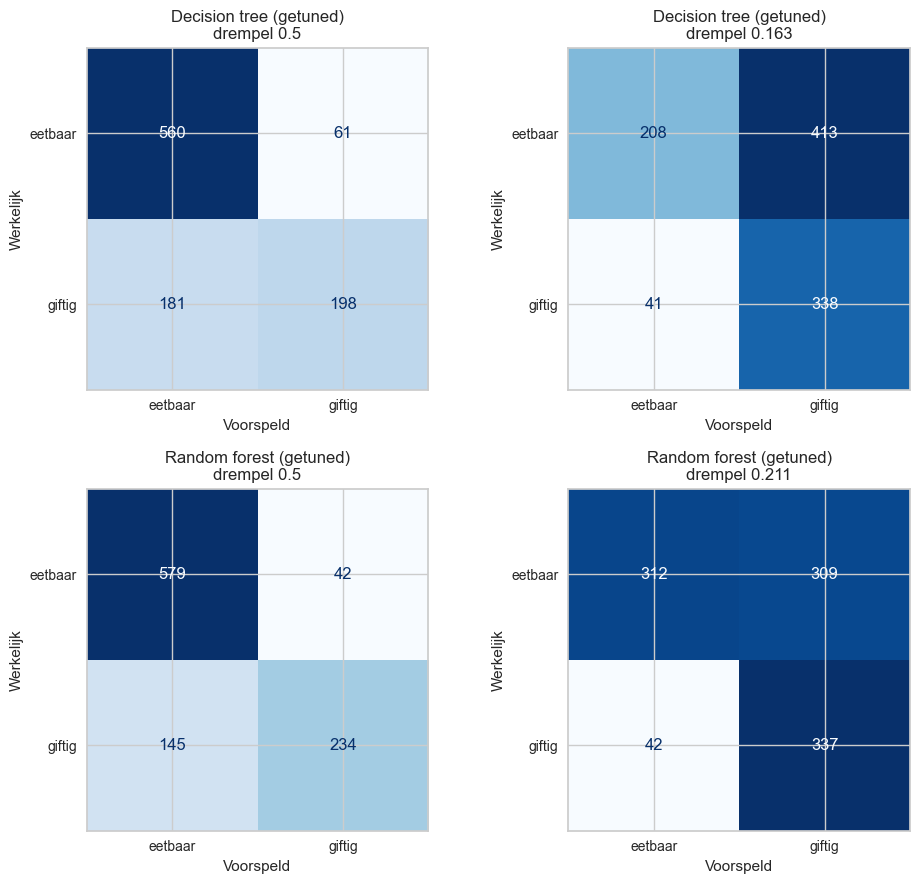

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row_axes, name in zip(axes, TUNED):
    for ax, threshold in zip(row_axes, [0.5, THRESHOLD[name]]):
        ConfusionMatrixDisplay.from_predictions(
            y_test, (test_proba[name] >= threshold).astype(int), display_labels=["eetbaar", "giftig"],
            cmap="Blues", values_format="d", colorbar=False, ax=ax,
        )
        ax.set_title(f"{name}\ndrempel {threshold}")
        ax.set_xlabel("Voorspeld")
        ax.set_ylabel("Werkelijk")
plt.tight_layout()
plt.show()

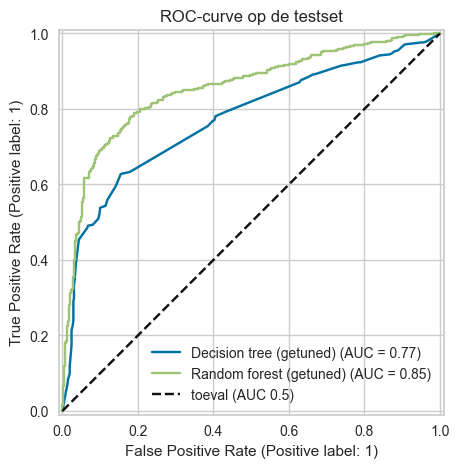

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
for name in TUNED:
    RocCurveDisplay.from_predictions(y_test, test_proba[name], name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="toeval (AUC 0.5)")
ax.set_title("ROC-curve op de testset")
ax.legend()
plt.show()

In [25]:
print(classification_report(y_test, (test_proba[best_name] >= THRESHOLD[best_name]).astype(int),
                            target_names=["eetbaar", "giftig"], digits=3))
zone_table(y_test, test_proba[best_name]).round(3)

              precision    recall  f1-score   support

     eetbaar      0.881     0.502     0.640       621
      giftig      0.522     0.889     0.658       379

    accuracy                          0.649      1000
   macro avg      0.702     0.696     0.649      1000
weighted avg      0.745     0.649     0.647      1000



,aantal,gelabeld_giftig,aandeel van alle paddenstoelen,% gelabeld giftig
zone,,,,
eetbaar,99,9,0.099,0.091
onzeker,255,33,0.255,0.129
giftig,646,337,0.646,0.522


**Drie zones op de testset:** 10% van de paddenstoelen krijgt "eetbaar". Van die 99 hebben er 9 (9%) het label giftig, hetzelfde als op de trainset (stap 5b). De zones gedragen zich dus op nieuwe data zoals verwacht. Het gaat wel om kleine aantallen: 9 rijen in 1.000.

### 6b. Hoe zeker zijn deze testcijfers? (bootstrap)

De testset telt 1.000 rijen. Met een andere steekproef van 1.000 paddenstoelen zouden de cijfers iets anders uitvallen. Hoeveel? Met de **bootstrap** trekken we 2.000 keer een nieuwe testset van 1.000 rijen uit de bestaande (met teruglegging) en berekenen we telkens de metrics. Het 95%-interval toont hoe ver de cijfers kunnen schommelen.

We trainen daarbij **niet** opnieuw: we schudden enkel de testrijen. Het interval meet dus de onzekerheid door de beperkte testset, niet die van het trainen.

In [26]:
N_BOOT = 2000
rng = np.random.default_rng(SEED)
p_rf, p_dt, yt = test_proba[best_name], test_proba["Decision tree (getuned)"], y_test.to_numpy()
t_rf = THRESHOLD[best_name]


def test_metrics(yy, pr, pdt):
    return {
        "AUC random forest": roc_auc_score(yy, pr),
        "AP random forest": average_precision_score(yy, pr),
        "accuracy RF (drempel 0,5)": ((pr >= 0.5) == yy).mean(),
        f"recall giftig RF (drempel {t_rf})": (pr[yy == 1] >= t_rf).mean(),
        f"specificity RF (drempel {t_rf})": (pr[yy == 0] < t_rf).mean(),
        "% gelabeld giftig in zone eetbaar": yy[pr < SAFE_THRESHOLD].mean(),
        "AUC decision tree": roc_auc_score(yy, pdt),
        "verschil AUC (RF - DT)": roc_auc_score(yy, pr) - roc_auc_score(yy, pdt),
    }


draws = [rng.integers(0, len(yt), len(yt)) for _ in range(N_BOOT)]
boot = pd.DataFrame([test_metrics(yt[i], p_rf[i], p_dt[i]) for i in draws])
pd.DataFrame({"gemeten": test_metrics(yt, p_rf, p_dt),
              "95%-interval van": boot.quantile(0.025), "tot": boot.quantile(0.975)}).round(3)

,gemeten,95%-interval van,tot
AUC random forest,0.854,0.828,0.879
AP random forest,0.804,0.761,0.843
"accuracy RF (drempel 0,5)",0.813,0.791,0.837
recall giftig RF (drempel 0.211),0.889,0.857,0.920
specificity RF (drempel 0.211),0.502,0.463,0.542
% gelabeld giftig in zone eetbaar,0.091,0.038,0.152
AUC decision tree,0.773,0.741,0.803
verschil AUC (RF - DT),0.081,0.056,0.108


**Interpretatie:**
- De test-AUC van de random forest ligt met 95% zekerheid tussen **0,83 en 0,88**. Met een andere testset van 1.000 paddenstoelen kan de score dus een paar honderdsten verschillen. Verschillen van ±0,01 tussen modellen kan je op deze testset niet zien; daarom kozen we de modellen op de cross-validation (stap 4).
- **De random forest is echt beter dan de decision tree**: het verschil in AUC ligt tussen 0,056 en 0,108, en het interval bevat 0 niet.
- De recall bij drempel 0,211 ligt tussen 86% en 92%. De 90% die we op de trainset kozen, wordt op de testset dus niet gegarandeerd. Dat is normaal bij 379 giftige testpaddenstoelen.
- Het aandeel gelabeld giftig in de zone "eetbaar" (9,1%) is erg onzeker: **3,8% tot 15,2%**. Het gaat maar om 99 paddenstoelen, waarvan 9 giftig gelabeld. Conclusies over die zone formuleren we daarom voorzichtig.

## 7. Welke kenmerken gebruikt de random forest?

We gebruiken **permutation importance** op de testset: we schudden één kolom door elkaar en kijken hoeveel de AUC zakt.
Een kolom waarvan de AUC niet zakt, gebruikt het model niet (of kan het missen).

Waarom niet de ingebouwde `feature_importances_`? Die werkt per one-hot-kolom (bv. `cap_shape_convex`), en ze overschat kolommen met veel verschillende waarden. Permutation importance werkt op de **originele** kolommen, en dat is makkelijker uit te leggen.

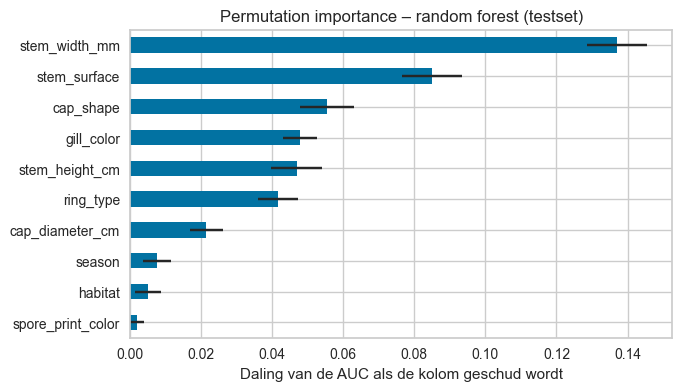

In [27]:
perm = permutation_importance(TUNED[best_name], X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=SEED)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot.barh(xerr=pd.Series(perm.importances_std, index=X_test.columns)[importance.index], ax=ax)
ax.set_xlabel("Daling van de AUC als de kolom geschud wordt")
ax.set_title("Permutation importance – random forest (testset)")
plt.show()

**Interpretatie:**
- De **steelbreedte** is veruit het belangrijkste kenmerk, gevolgd door `stem_surface`, `cap_shape`, `gill_color`, `stem_height_cm` en `ring_type`.
- `season`, `habitat` en `spore_print_color` dragen bijna niets bij. Bij `spore_print_color` is dat logisch: 95% is `"unknown"` (zie `01`).
- `stem_surface` is belangrijk ondanks 67% ontbrekende waarden. Dat bevestigt de keuze in `01` om `"unknown"` als eigen categorie te houden: ook "niet beschreven" zegt hier iets.

## 8. Error analysis: welke fouten maakt het model?

Een deel van de fouten is waarschijnlijk **geen fout van het model** maar een **omgedraaid label**. Als het model heel zeker is (kans < 10% of > 90%) en toch "fout" zit, is dat een kandidaat.
We kunnen dat niet bewijzen (we hebben geen juiste labels), maar het helpt om de score te begrijpen.

In [28]:
analysis = X_test.assign(werkelijk=y_test.map({0: "eetbaar", 1: "giftig"}), kans_giftig=test_proba[best_name].round(3))
wrong = (test_proba[best_name] >= 0.5).astype(int) != y_test
confident_wrong = wrong & ((test_proba[best_name] < 0.1) | (test_proba[best_name] > 0.9))

print(f"Fouten bij drempel 0.5          : {wrong.sum()} van {len(y_test)}")
print(f"  waarvan het model heel zeker is: {confident_wrong.sum()}")
analysis[confident_wrong].sort_values("kans_giftig").head(10)

Fouten bij drempel 0.5          : 187 van 1000
  waarvan het model heel zeker is: 11


,cap_diameter_cm,stem_height_cm,stem_width_mm,spore_print_color,gill_color,habitat,season,ring_type,cap_shape,stem_surface,werkelijk,kans_giftig
1420,NaN,6.44,10.03,unknown,white,leaves,winter,none,flat,smooth,giftig,0.033
1847,NaN,7.53,16.66,unknown,unknown,woods,unknown,none,convex,smooth,giftig,0.060
2528,NaN,5.09,12.68,unknown,brown,woods,summer,none,convex,unknown,giftig,0.077
1589,5.60,4.77,9.10,unknown,unknown,woods,autumn,none,flat,smooth,giftig,0.079
4211,6.32,NaN,11.17,unknown,white,urban,unknown,evanescent,flat,smooth,giftig,0.082
516,NaN,13.88,12.42,unknown,white,woods,summer,unknown,unknown,smooth,giftig,0.084
2226,NaN,NaN,17.69,unknown,orange,woods,autumn,none,sunken,unknown,giftig,0.086
3875,NaN,NaN,20.71,unknown,none,leaves,spring,none,unknown,unknown,giftig,0.088
1940,NaN,9.21,18.12,unknown,unknown,leaves,autumn,pendant,spherical,scaly,giftig,0.093
3325,NaN,15.87,8.12,unknown,white,woods,autumn,none,flat,grooves,eetbaar,0.936


Vergelijk de kansverdeling van de juiste en de foute voorspellingen:

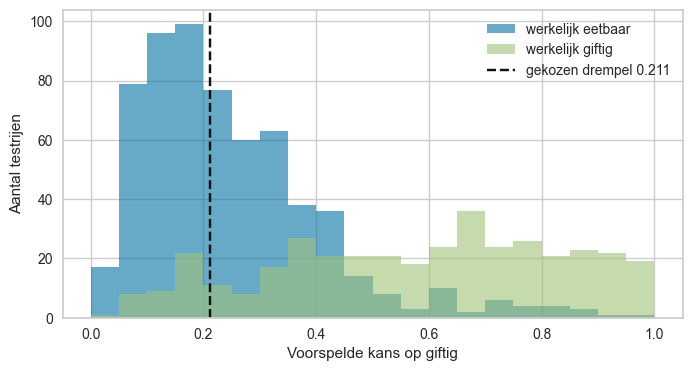

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, value in [("eetbaar", 0), ("giftig", 1)]:
    ax.hist(test_proba[best_name][y_test == value], bins=20, range=(0, 1), alpha=0.6, label=f"werkelijk {label}")
ax.axvline(THRESHOLD[best_name], color="k", linestyle="--", label=f"gekozen drempel {THRESHOLD[best_name]}")
ax.set_xlabel("Voorspelde kans op giftig")
ax.set_ylabel("Aantal testrijen")
ax.legend()
plt.show()

**Interpretatie:**
- Het model maakt 187 fouten op 1.000 bij drempel 0,5. Bij 11 daarvan is het heel zeker van zijn zaak. Dat zijn de beste kandidaten voor omgedraaide labels: rijen die er in alle kenmerken uitzien als de andere klasse.
- De twee verdelingen overlappen sterk tussen 0,1 en 0,5. Veel giftige paddenstoelen lijken met deze 10 (deels ontbrekende) kenmerken gewoon op eetbare. Daarom moet de drempel zo laag om 90% recall te halen.

### 8b. Zijn er labels omgedraaid, en hoeveel?

De opdracht zegt: *"may or may not have had some class-labels flipped"*. Tot nu toe was "labelruis" een vermoeden. Hier zoeken we **bewijs**, en schatten we hoeveel. We gebruiken enkel de trainset, en **niet** de UCI-versie (dat verbiedt de opdracht).

**Test 1: zijn er zuivere groepen?** In de originele dataset hoort elke soort bij één klasse. Groepen paddenstoelen met dezelfde kenmerken (bv. dezelfde ring én hetzelfde steeloppervlak) bestaan vaak uit één of enkele soorten, dus veel van die groepen zouden **100% zuiver** moeten zijn. Zijn labels willekeurig omgedraaid met kans ε, dan bevat **elke** groep ongeveer een fractie ε van het andere label, en is geen enkele grote groep zuiver.

In [30]:
purity_rows = []
for k in (1, 2, 3):
    for cols in itertools.combinations(CATEGORICAL, k):
        known = X_train[list(cols)].ne("unknown").all(axis=1)
        stats = y_train[known].groupby([X_train.loc[known, c] for c in cols], observed=True).agg(["size", "mean"])
        for values, row in stats[stats["size"] >= 30].iterrows():
            values = values if isinstance(values, tuple) else (values,)
            purity_rows.append({"groep": " & ".join(f"{c}={v}" for c, v in zip(cols, values)),
                                "rijen": int(row["size"]), "% giftig": row["mean"]})
purity = pd.DataFrame(purity_rows)
purity["% ander label"] = np.minimum(purity["% giftig"], 1 - purity["% giftig"])
print(f"{len(purity)} groepen van minstens 30 trainrijen | volledig zuivere groepen: {(purity['% ander label'] == 0).sum()}")
purity.sort_values("% ander label").head(10).round(3)

508 groepen van minstens 30 trainrijen | volledig zuivere groepen: 0


,groep,rijen,% giftig,% ander label
266,cap_shape=others & stem_surface=none,44,0.955,0.045
505,ring_type=none & cap_shape=others & stem_surfa...,42,0.952,0.048
188,habitat=woods & stem_surface=none,42,0.952,0.048
455,habitat=woods & ring_type=none & stem_surface=...,40,0.950,0.050
467,habitat=woods & cap_shape=others & stem_surfac...,39,0.949,0.051
42,stem_surface=none,49,0.939,0.061
252,ring_type=none & stem_surface=none,47,0.936,0.064
362,gill_color=white & season=summer & stem_surfac...,31,0.065,0.065
251,ring_type=none & stem_surface=grooves,50,0.920,0.080
324,gill_color=white & habitat=woods & stem_surfac...,62,0.081,0.081


**Test 2: de zekerste voorspellingen.** Waar het model (out-of-fold) heel zeker is, zou het label bijna altijd moeten kloppen. Wat daar toch "fout" is, is vooral een omgedraaid label.

In [31]:
p_oof = oof_proba[best_name]
noise = pd.DataFrame({
    "zeker eetbaar (kans < 0,10)": {"rijen": (p_oof < 0.10).sum(), "% met het andere label": y_train[p_oof < 0.10].mean()},
    "zeker giftig (kans > 0,90)": {"rijen": (p_oof > 0.90).sum(), "% met het andere label": 1 - y_train[p_oof > 0.90].mean()},
}).T
noise.round(3)

,rijen,% met het andere label
"zeker eetbaar (kans < 0,10)",355.0,0.090
"zeker giftig (kans > 0,90)",116.0,0.078


**Test 3: cleanlab (confident learning).** Een gepubliceerde methode (Northcutt et al.) die met de out-of-fold kansen per klasse schat hoeveel labels omgedraaid zijn. Ze telt ook echte modelfouten mee als "labelfout", dus het is eerder een **bovengrens**.

In [32]:
joint = estimate_joint(labels=y_train.values, pred_probs=np.column_stack([1 - p_oof, p_oof]))
flip = joint / joint.sum(axis=0, keepdims=True)  # rijen = gelabeld, kolommen = werkelijk -> P(gelabeld | werkelijk)
pd.Series({
    "werkelijk eetbaar -> gelabeld giftig": flip[1, 0],
    "werkelijk giftig -> gelabeld eetbaar": flip[0, 1],
    "geschat werkelijk % giftig": joint.sum(axis=0)[1],
    "gelabeld % giftig": y_train.mean(),
}).round(3).to_frame("cleanlab")

,cleanlab
werkelijk eetbaar -> gelabeld giftig,0.127
werkelijk giftig -> gelabeld eetbaar,0.140
geschat werkelijk % giftig,0.344
gelabeld % giftig,0.378


**Interpretatie:**
- **Test 1:** van de 508 groepen met minstens 30 trainrijen is er **geen enkele zuiver**. Zelfs de zuiverste groepen (bv. paddenstoelen zonder steel, `stem_surface=none`, slechts een paar soorten) bevatten 4,5–6% van het andere label. Dat geldt in beide richtingen: "giftige" groepen bevatten ±5% eetbare, "eetbare" groepen ±6,5–8% giftige. Zonder omgedraaide labels zouden veel van die groepen 100% zuiver zijn. **De labelruis is dus geen vermoeden meer, maar aangetoond.**
- **Test 2:** waar het model heel zeker is, heeft nog 9% (zeker eetbaar) en 8% (zeker giftig) het andere label.
- **Test 3:** cleanlab schat 12,7% (eetbaar → giftig) en 14,0% (giftig → eetbaar), en een werkelijk aandeel giftig van 34% in plaats van de gelabelde 38%.
- Elke test heeft een bekende fout. Test 1 schat te **laag** (we kiezen de zuiverste groepen, en die zijn deels toevallig zuiver). Test 2 en 3 schatten te **hoog** (ze tellen ook echte modelfouten mee). Samen: **±5–13% van de labels is omgedraaid, ongeveer even veel in beide richtingen**, met ±8% als middenwaarde.
- Een bijkomend inzicht: volgens de UCI-pagina is 55,5% van de originele paddenstoelen giftig, in onze dataset 37,9%. Symmetrisch omdraaien kan dat verschil niet verklaren. De docent heeft de rijen dus ook niet willekeurig gekozen. Voor ons model maakt dat niet uit, maar het verklaart waarom de klassen anders verdeeld zijn dan op de UCI-pagina.
- **Gevolg:** ook de **testset** bevat ±8% foute labels. Wat dat betekent voor al onze cijfers, rekenen we uit in stap 8d.

### 8c. Hoe goed is het model als er meer of minder ingevuld is?

Bijna elke paddenstoel mist minstens één kenmerk (zie `01`). We berekenen de AUC apart volgens het aantal ontbrekende kenmerken, en volgens het al dan niet ingevuld zijn van de twee belangrijkste kenmerken (stap 7). Weer op de out-of-fold voorspellingen (4.000 rijen), want de groepen in de testset zijn klein.

In [33]:
n_missing = X_train[NUMERIC].isna().sum(axis=1) + X_train[CATEGORICAL].eq("unknown").sum(axis=1)
groups = {
    "0–2 ontbrekend": n_missing <= 2, "3 ontbrekend": n_missing == 3,
    "4 ontbrekend": n_missing == 4, "5+ ontbrekend": n_missing >= 5,
    "stem_width_mm ingevuld": X_train["stem_width_mm"].notna(), "stem_width_mm ontbreekt": X_train["stem_width_mm"].isna(),
    "stem_surface ingevuld": X_train["stem_surface"].ne("unknown"), "stem_surface ontbreekt": X_train["stem_surface"].eq("unknown"),
}
pd.DataFrame({name: {"rijen": mask.sum(), "AUC": roc_auc_score(y_train[mask], p_oof[mask.values])}
              for name, mask in groups.items()}).T.round(3)

,rijen,AUC
0–2 ontbrekend,1284.0,0.877
3 ontbrekend,1354.0,0.826
4 ontbrekend,893.0,0.805
5+ ontbrekend,469.0,0.760
stem_width_mm ingevuld,3695.0,0.841
stem_width_mm ontbreekt,305.0,0.743
stem_surface ingevuld,1304.0,0.881
stem_surface ontbreekt,2696.0,0.805


**Interpretatie:**
- Hoe meer er ontbreekt, hoe slechter het model: van AUC **0,88** (0–2 ontbrekend) tot **0,76** (5 of meer). Een groot deel van de "slechte" score komt dus door onvolledige invoer, niet door het model.
- `stem_width_mm` (het belangrijkste kenmerk, stap 7): AUC 0,84 als het ingevuld is, 0,74 als het ontbreekt. Bij `stem_surface`: 0,88 tegenover 0,81.
- **Voor de webapp:** in een echte app hebben we wél invloed op de invoer. Velden als steelbreedte en steeloppervlak verplicht maken (of met een foto/uitleg helpen invullen) levert waarschijnlijk meer op dan elk ander model.

### 8d. Wat betekent de labelruis voor onze cijfers en onze drempel?

Alle scores in deze notebook, **ook die op de testset**, zijn gemeten tegen labels die zelf deels fout zijn. Een "gemiste giftige paddenstoel" kan dus ook een eetbare paddenstoel met een fout label zijn. We rekenen terug naar de **echte** scores.

**Aanname:** een label is met kans ε omgedraaid, in beide richtingen even vaak en **los van de kenmerken** (willekeurig). Test 1 en 2 in stap 8b steunen dat: het andere label komt in alle groepen en in beide klassen ongeveer even vaak voor, en cleanlab vindt in beide richtingen ongeveer dezelfde ruis.

**Hoe werkt de correctie?** Bij ruis ε is een paddenstoel met het label "giftig" met kans *a* echt giftig, en een paddenstoel met het label "eetbaar" met kans *b* toch giftig. *a* en *b* volgen uit ε en het gelabelde aandeel giftig. De gemeten recall is dan een mengeling van de echte recall en de echte foutpositieven:

&nbsp;&nbsp;&nbsp;&nbsp;gemeten recall = *a* · echte recall + (1 − *a*) · echte FPR
&nbsp;&nbsp;&nbsp;&nbsp;gemeten FPR = *b* · echte recall + (1 − *b*) · echte FPR

Twee vergelijkingen met twee onbekenden: die lossen we op. Zo ook voor de AUC en voor het aandeel giftig in de zone "eetbaar".

Omdat ε een schatting is, doen we het voor **meerdere waarden** (0% = geen correctie, zoals tot nu toe). Een conclusie die voor elke waarde klopt, is betrouwbaar.

In [34]:
def noise_mix(eps, q):
    """Symmetrische, willekeurige ruis eps bij een gelabeld aandeel giftig q."""
    pi = (q - eps) / (1 - 2 * eps)  # werkelijk aandeel giftig
    a = pi * (1 - eps) / q          # P(werkelijk giftig | gelabeld giftig)
    b = pi * eps / (1 - q)          # P(werkelijk giftig | gelabeld eetbaar)
    return pi, a, b


def true_rates(y_true, pred, eps):
    """Echte recall, specificity en accuracy, teruggerekend uit de gemeten waarden op ruisige labels."""
    y_true, pred = np.asarray(y_true), np.asarray(pred)
    pi, a, b = noise_mix(eps, y_true.mean())
    recall, fpr = np.linalg.solve([[a, 1 - a], [b, 1 - b]], [pred[y_true == 1].mean(), pred[y_true == 0].mean()])
    return {"recall": recall, "specificity": 1 - fpr, "accuracy": recall * pi + (1 - fpr) * (1 - pi)}


def true_auc(auc_measured, eps, q):
    """Echte AUC, en de AUC die een PERFECT model op deze ruisige labels zou halen."""
    pi, a, b = noise_mix(eps, q)
    slope, offset = a * (1 - b) - (1 - a) * b, 0.5 * (a * b + (1 - a) * (1 - b)) + (1 - a) * b
    return (auc_measured - offset) / slope, slope + offset


p_test = test_proba[best_name]
in_safe_zone = p_test < SAFE_THRESHOLD
sensitivity = {}
for eps in [0.0, 0.05, 0.08, 0.11]:
    auc_true, auc_perfect = true_auc(roc_auc_score(y_test, p_test), eps, y_test.mean())
    row = {"AUC (echt)": auc_true, "AUC die een perfect model zou meten": auc_perfect}
    for t in [0.5, THRESHOLD[best_name]]:
        row |= {f"{name} bij drempel {t}": value for name, value in true_rates(y_test, p_test >= t, eps).items()}
    row["% giftig in zone eetbaar"] = max((y_test[in_safe_zone].mean() - eps) / (1 - 2 * eps), 0)
    sensitivity[f"ruis {eps:.0%}"] = row
pd.DataFrame(sensitivity).round(3)

,ruis 0%,ruis 5%,ruis 8%,ruis 11%
AUC (echt),0.854,0.899,0.932,0.972
AUC die een perfect model zou meten,1.000,0.943,0.909,0.874
recall bij drempel 0.5,0.617,0.669,0.709,0.757
specificity bij drempel 0.5,0.932,0.951,0.963,0.977
accuracy bij drempel 0.5,0.813,0.848,0.873,0.901
recall bij drempel 0.211,0.889,0.926,0.954,0.989
specificity bij drempel 0.211,0.502,0.515,0.524,0.534
accuracy bij drempel 0.211,0.649,0.666,0.677,0.691
% giftig in zone eetbaar,0.091,0.045,0.013,0.000


**Interpretatie:**
- **Het model is beter dan we gemeten hebben**, bij elke ruiswaarde. Bij 5–11% ruis is de echte AUC 0,90–0,97 (gemeten 0,854), de echte accuracy bij drempel 0,5 85–90% (gemeten 81%) en de echte recall bij drempel 0,211 93–99% (gemeten 89%).
- **Het plafond:** zelfs een **perfect** model zou op deze testset maar een AUC van 0,87–0,94 meten. Onze 0,854 ligt daar niet ver onder. Dat bevestigt de conclusie van stap 4 met cijfers: er valt met een ander model weinig te winnen, want de antwoordsleutel zelf is fout.
- **De zone "eetbaar" is veiliger dan ze leek.** Van de 9,1% gelabeld giftig is het grootste deel waarschijnlijk een eetbare paddenstoel met een fout label: bij 5% ruis blijft er 4,5% echt giftig over, bij 8% ruis 1,3%. Het gaat wel om kleine aantallen (9 van 99 testrijen), dus dit blijft een schatting.
- **Dit verklaart ook waarom niets in stap 4 hielp.** Bij willekeurig omgedraaide labels blijft de **volgorde** van de kansen behouden: de paddenstoel die het meest op een giftige lijkt, krijgt nog altijd de hoogste kans. Het beste model op de ruisige labels is dus ook het beste op de echte labels, en labels opkuisen (stap 4d) verandert die volgorde niet. Wat de ruis wel verstoort, is de **schaal**: de kansen worden naar het midden gedrukt (daarom zijn kansen > 0,9 zeldzaam) en de gemeten recall valt te laag uit.
- **Aanname:** de labels zijn willekeurig omgedraaid, los van de kenmerken. Test 1 en 3 in stap 8b steunen dat, maar bewijzen kan niet zonder de juiste labels.

**Een ruisbewuste drempel.** In stap 5 kozen we de drempel zodat de **gemeten** recall ≥ 90%. Maar gemeten recall is lager dan echte recall: een deel van de "gemiste giftige" is eigenlijk eetbaar. We kiezen nu de hoogste drempel waarbij de **echte** recall ≥ 90%, weer op de out-of-fold voorspellingen van de trainset.

Voor ε nemen we **5%**: de voorzichtige onderkant van de schattingen in 8b. Hoe lager ε, hoe kleiner de correctie en hoe lager (veiliger) de drempel. Daarna kijken we één keer hoe die drempel het doet op de testset.

In [35]:
EPS_SAFE = 0.05  # voorzichtige ondergrens van de schatting in 8b


def choose_threshold_true(y_true, proba, eps, min_recall=MIN_RECALL):
    """Hoogste drempel met ECHTE recall >= min_recall (zelfde werkwijze als choose_threshold in stap 5)."""
    for t in np.sort(np.unique(proba))[::-1]:
        if true_rates(y_true, proba >= t, eps)["recall"] >= min_recall:
            return float(np.floor(t * 1000) / 1000)
    raise ValueError(f"Een echte recall van {min_recall:.0%} is bij geen enkele drempel haalbaar")


NOISE_THRESHOLD = choose_threshold_true(y_train, p_oof, EPS_SAFE)
comparison = {}
for label, t in [("drempel stap 5", THRESHOLD[best_name]), ("ruisbewuste drempel", NOISE_THRESHOLD)]:
    for part, yy, pp in [("train (out-of-fold)", y_train, p_oof), ("test", y_test, p_test)]:
        measured, true = evaluate_threshold(yy, pp, t), true_rates(yy, pp >= t, EPS_SAFE)
        comparison[(label, part)] = {
            "drempel": t, "gemeten recall": measured["recall giftig"],
            "gemeten specificity": measured["specificity (eetbaar herkend)"],
            "echte recall (ruis 5%)": true["recall"], "echte specificity (ruis 5%)": true["specificity"],
            "eetbaar onterecht giftig (FP)": measured["onterecht giftig (FP)"],
        }
pd.DataFrame(comparison).T.round(3)

drempel  gemeten recall  \
drempel stap 5      train (out-of-fold)    0.211           0.900   
                    test                   0.211           0.889   
ruisbewuste drempel train (out-of-fold)    0.246           0.863   
                    test                   0.246           0.865   

                                         gemeten specificity  \
drempel stap 5      train (out-of-fold)                0.435   
                    test                               0.502   
ruisbewuste drempel train (out-of-fold)                0.529   
                    test                               0.583   

                                         echte recall (ruis 5%)  \
drempel stap 5      train (out-of-fold)                   0.932   
                    test                                  0.926   
ruisbewuste drempel train (out-of-fold)                   0.900   
                    test                                  0.908   

                                         echte specificity (ruis 5%)  \
drempel stap 5      train (out-of-fold)                        0.446   
                    test                                       0.515   
ruisbewuste drempel train (out-of-fold)                        0.542   
                    test                                       0.598   

                                         eetbaar onterecht giftig (FP)  
drempel stap 5      train (out-of-fold)                         1404.0  
                    test                                         309.0  
ruisbewuste drempel train (out-of-fold)                         1171.0  
                    test                                         259.0

**Hoe zeker is die echte recall?** Ook hier gebruiken we de bootstrap (dezelfde 2.000 trekkingen als in stap 6b), nu voor de gecorrigeerde recall en specificity bij beide drempels.

In [36]:
boot_true = []
for i in draws:
    row = {}
    for label, t in [("drempel stap 5", THRESHOLD[best_name]), ("ruisbewuste drempel", NOISE_THRESHOLD)]:
        true = true_rates(yt[i], p_test[i] >= t, EPS_SAFE)
        row[f"echte recall ({label})"], row[f"echte specificity ({label})"] = true["recall"], true["specificity"]
    boot_true.append(row)
boot_true = pd.DataFrame(boot_true)
pd.DataFrame({"95%-interval van": boot_true.quantile(0.025), "tot": boot_true.quantile(0.975),
              "kans dat recall < 90%": (boot_true < 0.90).mean().where(boot_true.columns.str.startswith("echte recall"))}).round(3)

,95%-interval van,tot,kans dat recall < 90%
echte recall (drempel stap 5),0.891,0.961,0.072
echte specificity (drempel stap 5),0.475,0.557,NaN
echte recall (ruisbewuste drempel),0.868,0.947,0.350
echte specificity (ruisbewuste drempel),0.558,0.637,NaN


**Interpretatie:**
- De ruisbewuste drempel is **0,246** (stap 5: 0,211). Op de trainset is de **gemeten** recall daarmee 86,3%, onder de 90%. De **echte** recall is wel 90,0%: het verschil zijn paddenstoelen die we "missen", maar die vermoedelijk eetbaar zijn met een fout label.
- **Op de testset** gooit de nieuwe drempel **50 eetbare paddenstoelen minder** onterecht weg (259 in plaats van 309). De echte specificity stijgt van 51,5% naar 59,8%, en de echte recall is 90,8%.
- **Maar de bootstrap toont de prijs.** De ruisbewuste drempel mikt **precies** op 90%: de echte recall ligt tussen 86,8% en 94,7%, met **35% kans onder 90%**. De drempel van stap 5 heeft, gecorrigeerd voor de ruis, een ingebouwde **veiligheidsmarge**: echte recall 89,1–96,1%, met maar 7% kans onder 90%. De winst van 50 eetbare paddenstoelen komt dus voor een deel uit het opgeven van die marge.
- Gemeten "mist" de nieuwe drempel 9 giftige paddenstoelen meer (recall 88,9% → 86,5%). Bij 5% ruis zijn de meeste daarvan eetbare paddenstoelen met een fout label.
- We kozen de **voorzichtige** ruisschatting (5%). Bij 8% ruis zou de drempel nog hoger mogen (±0,29), maar als de echte ruis lager ligt, zakt de echte recall dan onder 90%.

> 💬 *Teamkeuze:* beide drempels zijn te verdedigen. **0,246** haalt het doel "90% echte recall" en gooit minder eetbare paddenstoelen weg. **0,211** haalt het doel met bijna zekerheid (marge). In de opgeslagen zones gebruiken we 0,246; wil het team de marge, dan is het één getal in `deploy_zones`.
- **Zones voor de webapp:** "eetbaar" onder 0,096, "onzeker" van 0,096 tot 0,246, "giftig" vanaf 0,246. Op de testset is dat 10% eetbaar, 31% onzeker en 59% giftig.

## 9. Opslaan

We slaan beide gekozen pipelines op (preprocessing + model) en de metrics als JSON. Voor de webapp bewaren we de drie zones met de **ruisbewuste drempel** uit stap 8d: "eetbaar" onder `safe_threshold`, "giftig" vanaf `threshold_noise_aware`, en daartussen "onzeker". Het model wordt **niet** opnieuw getraind op train + test, zodat de opgeslagen scores horen bij exact het opgeslagen model.

> De modellen zijn opgeslagen met de versies uit `venv_pycaret` (scikit-learn 1.4.2). De backend moet dezelfde scikit-learn-versie gebruiken om ze te kunnen inladen.

In [37]:
(MODEL_DIR / "metrics").mkdir(parents=True, exist_ok=True)
FILES = {"Decision tree (getuned)": "decision_tree", "Random forest (getuned)": "random_forest"}
SEARCHES = {"Decision tree (getuned)": dt_search, "Random forest (getuned)": rf_search}

all_metrics = {}
for name, file in FILES.items():
    joblib.dump(TUNED[name], MODEL_DIR / f"{file}.pkl", compress=3)
    at_05 = evaluate_threshold(y_test, test_proba[name], 0.5)
    at_t = evaluate_threshold(y_test, test_proba[name], THRESHOLD[name])
    all_metrics[file] = {
        "notebook": "02_modeling",
        "model": name,
        "params": {k.split("__")[1]: v for k, v in SEARCHES[name].best_params_.items()},
        "cv_auc": round(float(results.loc[name, "CV AUC"]), 4),
        "threshold": THRESHOLD[name],
        "test_auc": round(float(roc_auc_score(y_test, test_proba[name])), 4),
        "test_accuracy_at_0.5": round(float(at_05["accuracy"]), 4),
        "test_recall_poisonous_at_0.5": round(float(at_05["recall giftig"]), 4),
        "test_accuracy": round(float(at_t["accuracy"]), 4),
        "test_recall_poisonous": round(float(at_t["recall giftig"]), 4),
        "test_specificity": round(float(at_t["specificity (eetbaar herkend)"]), 4),
    }
    if name == best_name:
        zones = zone_table(y_test, test_proba[name])
        all_metrics[file] |= {
            "safe_threshold": SAFE_THRESHOLD,
            "noise_eps_used": EPS_SAFE,
            "threshold_noise_aware": NOISE_THRESHOLD,
            "deploy_zones": {"eetbaar_onder": SAFE_THRESHOLD, "giftig_vanaf": NOISE_THRESHOLD},
            "test_share_safe_edible": round(float(zones.loc["eetbaar", "aandeel van alle paddenstoelen"]), 4),
            "test_poisonous_in_safe_zone": round(float(zones.loc["eetbaar", "% gelabeld giftig"]), 4),
        }
    (MODEL_DIR / "metrics" / f"{file}.json").write_text(json.dumps(all_metrics[file], indent=2))
    print(f"{file}.pkl: {(MODEL_DIR / f'{file}.pkl').stat().st_size / 1e6:.1f} MB")

pd.DataFrame(all_metrics).T.drop(columns=["notebook", "params"])

decision_tree.pkl: 0.0 MB


random_forest.pkl: 9.8 MB


,model,cv_auc,threshold,test_auc,test_accuracy_at_0.5,test_recall_poisonous_at_0.5,test_accuracy,test_recall_poisonous,test_specificity,safe_threshold,noise_eps_used,threshold_noise_aware,deploy_zones,test_share_safe_edible,test_poisonous_in_safe_zone
decision_tree,Decision tree (getuned),0.7697,0.163,0.7731,0.758,0.5224,0.546,0.8918,0.3349,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,Random forest (getuned),0.836,0.211,0.8538,0.813,0.6174,0.649,0.8892,0.5024,0.096,0.05,0.246,"{'eetbaar_onder': 0.096, 'giftig_vanaf': 0.246}",0.099,0.0909


Controle: kan het opgeslagen model een nieuwe paddenstoel voorspellen, zoals de backend dat zal doen? We geven één rij in met ontbrekende waarden (NaN en `"unknown"`).

In [38]:
loaded = joblib.load(MODEL_DIR / "random_forest.pkl")
example = X_test.head(1)
proba = loaded.predict_proba(example)[0, 1]
print(example.T.squeeze().to_dict())
print(f"\nKans op giftig: {proba:.2f} → zone: {zone(np.array([proba]), threshold=NOISE_THRESHOLD)[0].upper()}")

{'cap_diameter_cm': nan, 'stem_height_cm': 6.42, 'stem_width_mm': 13.51, 'spore_print_color': 'unknown', 'gill_color': 'unknown', 'habitat': 'woods', 'season': 'summer', 'ring_type': 'grooved', 'cap_shape': 'convex', 'stem_surface': 'unknown'}

Kans op giftig: 0.14 → zone: ONZEKER


## Conclusie

| Model | CV AUC | Test AUC | Test accuracy (0,5) | Test recall giftig (0,5) | Drempel | Test recall giftig | Test specificity |
|---|---|---|---|---|---|---|---|
| Dummy | 0,50 | – | ±62% | 0% | – | – | – |
| Decision tree (getuned) | 0,77 | 0,77 | 76% | 52% | 0,163 | 89% | 33% |
| **Random forest (getuned)** | **0,84** | **0,85** | **81%** | 62% | 0,211 | 89% | 50% |
| **Random forest, ruisbewuste drempel** | | | | | **0,246** | 86% gemeten, **91% echt** | 58% gemeten, **60% echt** |

*"Echt" = gecorrigeerd voor 5% omgedraaide labels (stap 8d).*

**Zones voor de webapp** (random forest): "eetbaar" onder 0,096, "onzeker" van 0,096 tot 0,246, "giftig" vanaf 0,246. Op de testset: 10% eetbaar, 31% onzeker, 59% giftig.

**Het belangrijkste inzicht: de labels zijn deels fout, ook in de testset.**
- In stap 8b tonen we aan dat **±5–13% van de labels omgedraaid** is: geen enkele groep gelijkaardige paddenstoelen is zuiver, en drie onafhankelijke methodes (waaronder cleanlab) geven dezelfde orde van grootte.
- Daardoor zijn **al onze cijfers te pessimistisch**. Gecorrigeerd is de echte AUC ±0,90–0,93 en de echte accuracy ±85–87% (stap 8d). Zelfs een perfect model zou op deze testset maar een AUC van ±0,91 meten: we zitten dicht tegen het plafond.
- Het verklaart waarom **geen enkel ander model** beter deed (stap 4, 24 alternatieven: PyCaret, boosting, XGBoost, stacking, andere preprocessing, labels opkuisen). Willekeurige labelruis verandert de volgorde van de kansen niet, alleen de schaal, dus het beste model blijft hetzelfde. De sterke modellen maken ook dezelfde fouten (correlatie 0,92–0,94, stap 4c).
- Het levert ook **winst** op: met een drempel die rekening houdt met de ruis, gooien we op de testset **50 eetbare paddenstoelen minder** weg, bij een echte recall van ±91%. De bootstrap toont wel dat die drempel geen veiligheidsmarge meer heeft (35% kans op een echte recall onder 90%, tegenover 7% bij drempel 0,211). Welke drempel de webapp gebruikt, is een teamkeuze (stap 8d).

**Verder:**
- De **random forest** is het beste model: hogere AUC dan de decision tree, en bij dezelfde recall veel minder eetbare paddenstoelen onterecht weggegooid. De testscores liggen binnen de spreiding van de CV-scores (test-AUC 0,854, 95%-interval 0,83–0,88): geen teken van overfitting.
- **Regularisatie** was de belangrijkste verbetering voor de boom (`max_leaf_nodes`, `min_samples_leaf`).
- **De cleaningkeuzes uit `01` zijn bevestigd** (stap 4e): elke keuze terugdraaien maakt het model even goed of slechter. De belangrijkste is `"unknown"` als eigen categorie (+0,012 AUC tegenover de modus).
- **Statistische zekerheid:** alle modellen zijn fold per fold vergeleken (stap 4f), en de testcijfers hebben een bootstrap-interval (stap 6b). De random forest is echt beter dan de decision tree (verschil in test-AUC 0,06–0,11); de alternatieven uit stap 4 zijn nooit consistent beter.
- **Twee drempels combineren** of een tweede model voor de twijfelgevallen helpt niet: zonder nieuwe informatie blijft de twijfel (stap 5c).
- **Ontbrekende kenmerken** zijn de tweede grote beperking: met 0–2 ontbrekende kenmerken is de AUC 0,88, met 5 of meer maar 0,76 (stap 8c).
- **Aanbeveling voor de webapp:** toon de drie zones, en vraag bij "onzeker" om de ontbrekende kenmerken aan te vullen (vooral `stem_width_mm` en `stem_surface`) en voorspel opnieuw: een tweede stap mét nieuwe informatie.
- **Veiligheid:** ook met de correctie noemen we ±40% van de eetbare paddenstoelen "giftig" om 90% van de giftige te vangen. Een app op basis van dit model geeft een **indicatie**, geen eetadvies.
- **Beperkingen:** de correctie veronderstelt dat de labels willekeurig omgedraaid zijn, en het ruisniveau is een schatting (daarom de voorzichtige 5%). Er is geen soortkolom, dus exemplaren van dezelfde soort kunnen in train én test zitten (zie `01`, stap 12).

**Model voor deployment:** `models/random_forest.pkl`, met de zones uit `models/metrics/random_forest.json` (`deploy_zones`).